# Fenología del café y ciclo climático estacional en Colombia
## Análisis ERA5 + Índice Niño 3.4
### Santiago Castaño Moreno — Física del Clima y Cambio Climático 2026-1

**Estructura del notebook:**
1. Importación de librerías y configuración
2. Carga y preprocesamiento de datos ERA5
3. Carga del índice Niño 3.4
4. Ciclo estacional: climatología mensual
5. Análisis espectral
6. Correlación Pearson: Niño 3.4 vs variables climáticas
7. Clasificación de años ENOS y composites de anomalías
8. Evaluación fenológica: umbrales climáticos del cafeto
9. Síntesis: impacto del ENOS sobre el calendario fenológico

---
**Nota sobre unidades ERA5 (`stepType=avgad`):**  
`tp` y `pev` vienen en **m/día promedio**. La conversión a mm/mes es:
`variable_mm_mes = variable_raw × 1000 × días_del_mes`


In [9]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
from scipy import signal, stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
})

MESES = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']
print("Librerías cargadas.")


Librerías cargadas.


## 1. Configuración de departamentos

Cada departamento requiere dos archivos `.nc`:
- `*avgad*` → `tp` (precipitación, m/día) y `pev` (evapotranspiración potencial, m/día)
- `*avgua*` → `t2m` (temperatura a 2 m, Kelvin)

Ajusta el diccionario `DEPARTAMENTOS` con las rutas a tus archivos.


In [10]:
# ── AJUSTA AQUÍ LAS RUTAS ────────────────────────────────────────────────────
DEPARTAMENTOS = {
    'Risaralda': (
        '/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/RISARALDA/data_stream-moda_stepType-avgad.nc',
        '/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/RISARALDA/data_stream-moda_stepType-avgua.nc',
    ),
     'Caldas': ('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/CALDAS/data_stream-moda_stepType-avgad.nc', '/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/CALDAS/data_stream-moda_stepType-avgua.nc'),
     'Quindio': ('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/QUINDIO/data_stream-moda_stepType-avgad.nc', '/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/QUINDIO/data_stream-moda_stepType-avgua.nc'),
     'Huila':   ('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/HUILA/data_stream-moda_stepType-avgad.nc',   '/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/HUILA/data_stream-moda_stepType-avgua.nc'),
}

COLORES = {
    'Risaralda': '#2196F3',
    'Caldas':    '#4CAF50',
    'Quindio':   '#FF9800',
    'Huila':     '#9C27B0',
}

# Etapas fenológicas (Arcila et al. 2007; Jaramillo 2005)
ETAPAS = [
    {'nombre': 'Inducción\nfloral',   'meses': [12, 1],    'color': '#FFA07A'},
    {'nombre': 'Floración',             'meses': [2,  3],    'color': '#98FB98'},
    {'nombre': 'Desarrollo\nfruto',   'meses': [4,  5, 6], 'color': '#87CEEB'},
    {'nombre': 'Maduración',            'meses': [7,  8, 9], 'color': '#DDA0DD'},
    {'nombre': 'Cosecha',               'meses': [10, 11],   'color': '#F0E68C'},
]

print("Configuración lista.")
print(f"Departamentos: {list(DEPARTAMENTOS.keys())}")


Configuración lista.
Departamentos: ['Risaralda', 'Caldas', 'Quindio', 'Huila']


## 2. Carga y preprocesamiento de datos ERA5

In [11]:
def cargar_departamento(archivo_avgad, archivo_avgua):
    """
    Carga los dos archivos ERA5, promedia espacialmente y devuelve
    un DataFrame mensual con columnas: tp_mm, pev_mm, t2m_c, bh_mm.

    Conversión de unidades:
      - tp  (m/día)  → mm/mes : × 1000 × días_del_mes
      - pev (m/día)  → mm/mes : × 1000 × días_del_mes  (valor absoluto)
      - t2m (K)      → °C     : − 273.15
      - bh  (mm/mes) = tp_mm − pev_mm

    NOTA ERA5: 'valid_time' en archivos mensuales suele apuntar al último
    día del mes (ej. 1950-01-31). Se normaliza al primer día para que la
    intersección con el índice Niño 3.4 (day=1) siempre tenga matches.
    """
    ds_ad = xr.open_dataset(archivo_avgad)
    ds_ua = xr.open_dataset(archivo_avgua)

    tiempo_raw = pd.DatetimeIndex(ds_ad['valid_time'].values)
    # ── CORRECCIÓN: normalizar al primer día del mes ──────────────────────
    tiempo = pd.DatetimeIndex([
        pd.Timestamp(year=t.year, month=t.month, day=1)
        for t in tiempo_raw
    ])
    dias = np.array(tiempo_raw.days_in_month, dtype=float)  # días reales del mes

    tp_mm  = ds_ad['tp'].mean(dim=['latitude','longitude']).values  * 1000 * dias
    pev_mm = np.abs(
             ds_ad['pev'].mean(dim=['latitude','longitude']).values) * 1000 * dias
    t2m_c  = ds_ua['t2m'].mean(dim=['latitude','longitude']).values - 273.15
    bh_mm  = tp_mm - pev_mm

    ds_ad.close()
    ds_ua.close()

    df = pd.DataFrame(
        {'tp_mm': tp_mm, 'pev_mm': pev_mm, 't2m_c': t2m_c, 'bh_mm': bh_mm},
        index=tiempo
    ).sort_index()
    df.index.name = 'fecha'
    return df


DATOS = {}
for depto, (f_ad, f_ua) in DEPARTAMENTOS.items():
    DATOS[depto] = cargar_departamento(f_ad, f_ua)
    d = DATOS[depto]
    print(f"{depto}: {len(d)} meses | "
          f"T={d['t2m_c'].mean():.1f}°C | "
          f"PP={d['tp_mm'].mean():.0f} mm/mes | "
          f"ETP={d['pev_mm'].mean():.0f} mm/mes | "
          f"BH={d['bh_mm'].mean():.0f} mm/mes")


Risaralda: 888 meses | T=17.7°C | PP=650 mm/mes | ETP=79 mm/mes | BH=571 mm/mes
Caldas: 888 meses | T=19.5°C | PP=316 mm/mes | ETP=94 mm/mes | BH=222 mm/mes
Quindio: 888 meses | T=15.7°C | PP=644 mm/mes | ETP=84 mm/mes | BH=560 mm/mes
Huila: 888 meses | T=19.7°C | PP=252 mm/mes | ETP=90 mm/mes | BH=163 mm/mes


## 3. Índice Niño 3.4

Descarga la serie de anomalías mensuales desde:
**https://psl.noaa.gov/data/climateindices/list/** → *Nino 3.4 (ERSSTv5)*

Guarda el archivo como `nino34.txt` en el mismo directorio.  
Formato esperado: `año | ene feb mar abr may jun jul ago sep oct nov dic`


Niño 3.4: 1950-01-01 → 2023-12-01
N=888 meses | máx=2.72 °C (2015-11-01) | mín=-2.45 °C (1955-11-01)


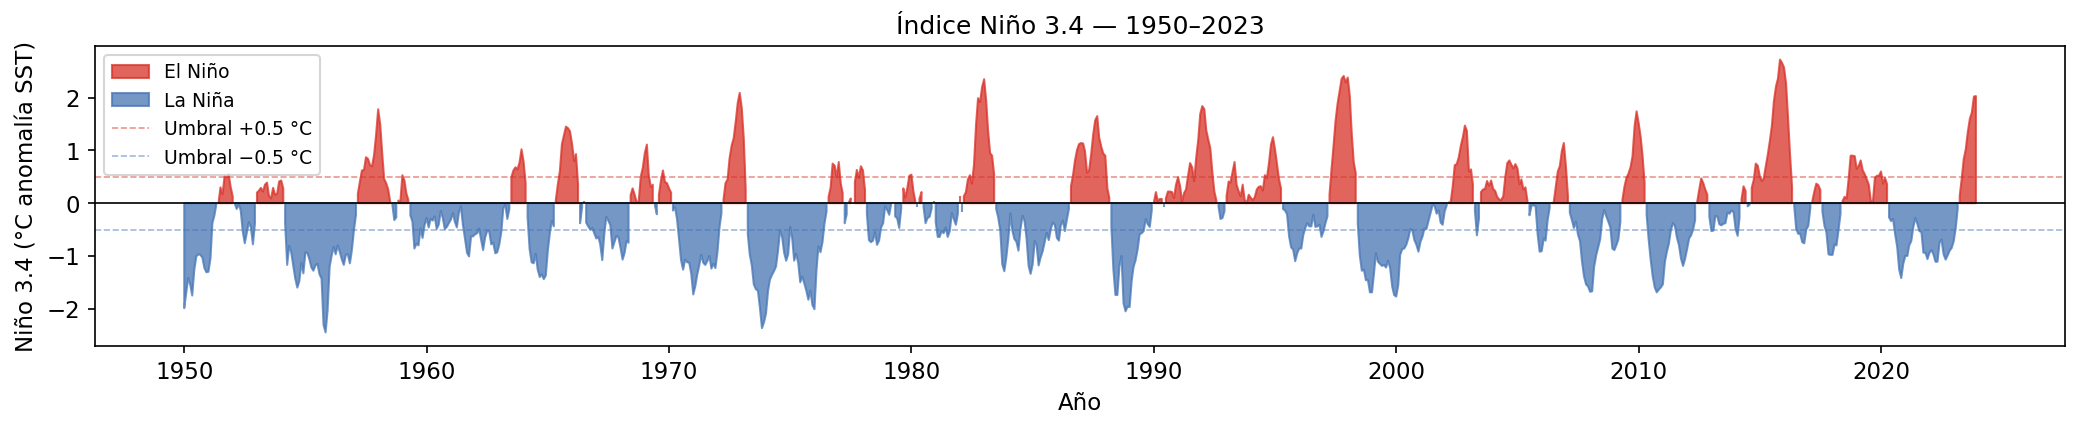

In [12]:
## 3. Índice Niño 3.4 (desde datos_nino.xlsx)
#
# El archivo Excel contiene las columnas:
#   YR, MON, NINO1+2, ANOM, NINO3, ANOM, NINO4, ANOM, NINO3.4, ANOM3.4
# Usamos ANOM3.4 (anomalías mensuales de la región Niño 3.4).
# CORRECCIÓN: NO se estandariza la serie para preservar las unidades físicas
# (°C de anomalía SST). El umbral de clasificación ENOS (±0.5 °C) tiene
# significado físico directo sobre la serie sin estandarizar.
#

def cargar_nino34_desde_excel(ruta='datos_nino.xlsx', anio_ini=1950, anio_fin=2023):
    """
    Lee el índice Niño 3.4 (anomalías SST en °C) desde el archivo Excel,
    filtra el período solicitado. NO estandariza: se conservan las unidades
    físicas para que el umbral ±0.5 °C sea coherente con la clasificación NOAA.
    """
    df_raw = pd.read_excel(ruta, sheet_name='Hoja1')
    required_cols = ['YR', 'MON', 'ANOM3.4']
    for col in required_cols:
        if col not in df_raw.columns:
            raise KeyError(f"El archivo Excel no contiene la columna '{col}'")
    df_raw = df_raw[(df_raw['YR'] >= anio_ini) & (df_raw['YR'] <= anio_fin)].copy()
    fechas = [pd.Timestamp(year=int(row['YR']), month=int(row['MON']), day=1)
              for _, row in df_raw.iterrows()]
    valores = df_raw['ANOM3.4'].values.astype(float)
    serie = pd.Series(valores, index=fechas, name='nino34').sort_index()
    return serie

# Cargar la serie (ajusta la ruta si el archivo está en otra carpeta)
nino34 = cargar_nino34_desde_excel('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto_final/DATOS/datos_nino.xlsx')

print(f"Niño 3.4: {nino34.index[0].date()} → {nino34.index[-1].date()}")
print(f"N={len(nino34)} meses | máx={nino34.max():.2f} °C ({nino34.idxmax().date()})"
      f" | mín={nino34.min():.2f} °C ({nino34.idxmin().date()})")

fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(nino34.index, nino34, 0,
                where=nino34 >= 0,  color='#d73027', alpha=0.75, label='El Niño')
ax.fill_between(nino34.index, nino34, 0,
                where=nino34 < 0,   color='#4575b4', alpha=0.75, label='La Niña')
ax.axhline(0,    color='k',       lw=0.8)
ax.axhline( 0.5, color='#d73027', lw=0.8, ls='--', alpha=0.5, label='Umbral +0.5 °C')
ax.axhline(-0.5, color='#4575b4', lw=0.8, ls='--', alpha=0.5, label='Umbral −0.5 °C')
ax.set(xlabel='Año', ylabel='Niño 3.4 (°C anomalía SST)',
       title='Índice Niño 3.4 — 1950–2023')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig01_nino34.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Ciclo estacional — climatología mensual

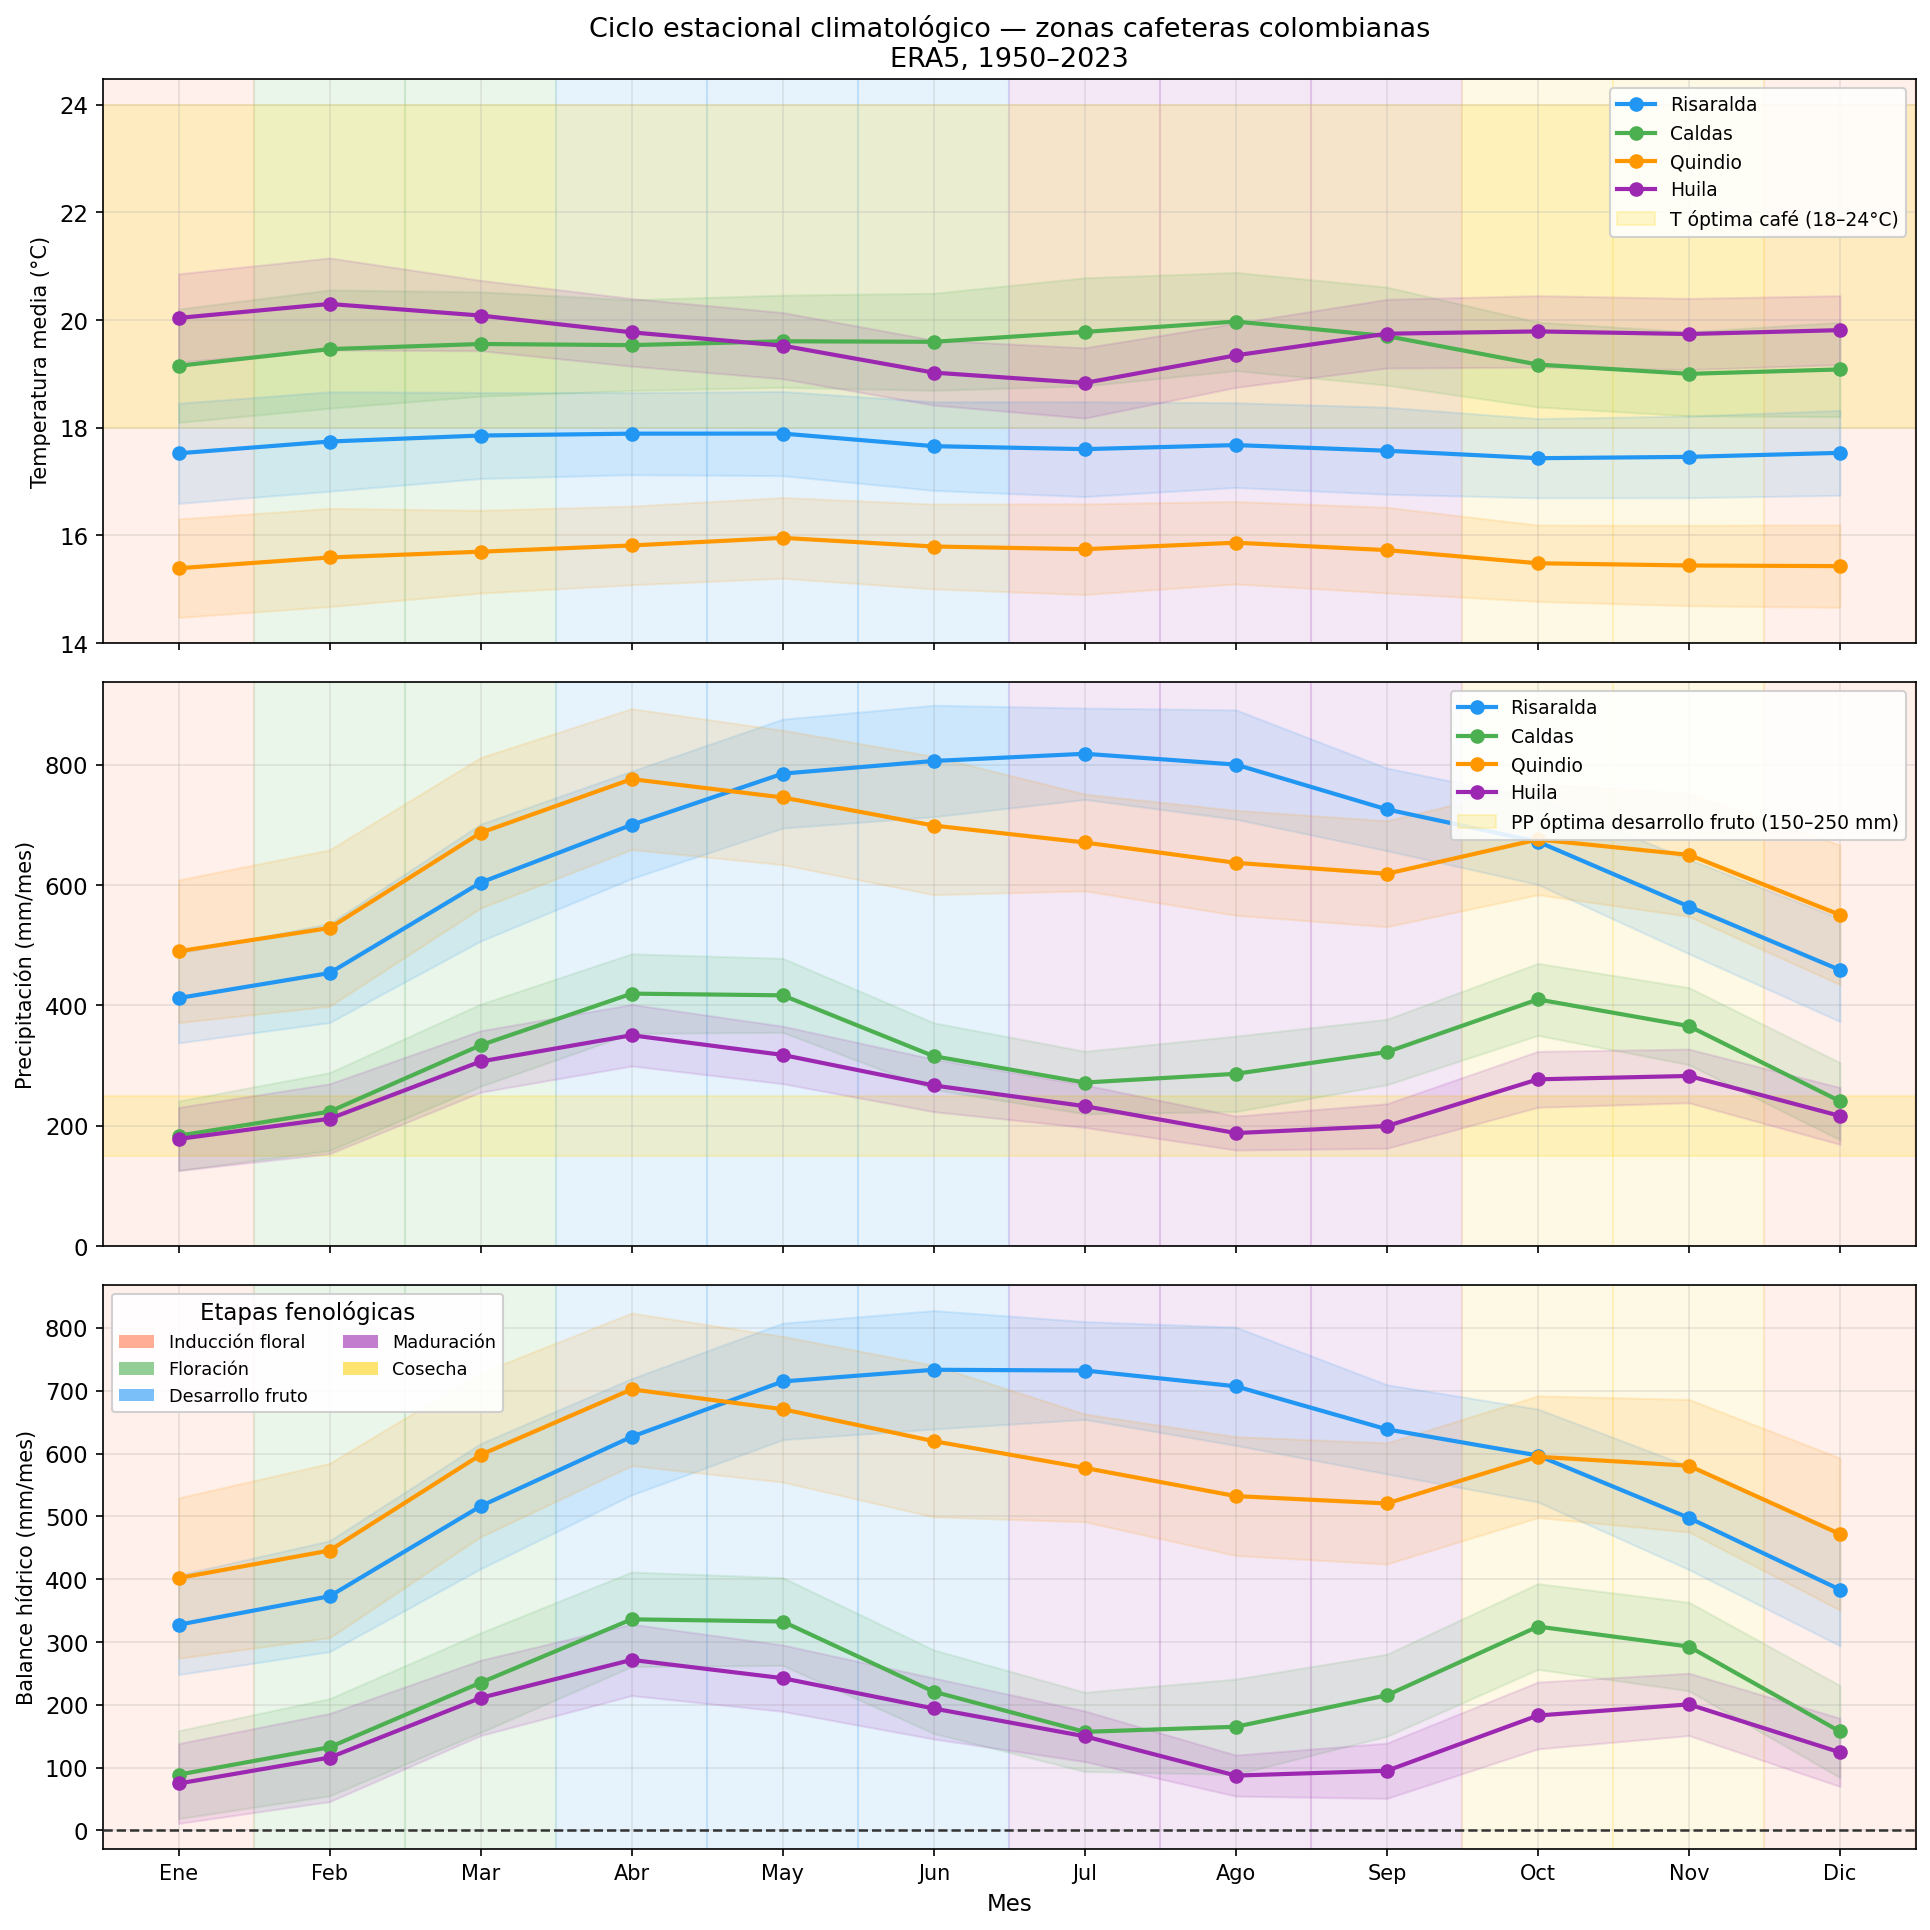

In [13]:
CLIM = {d: DATOS[d].groupby(DATOS[d].index.month).agg(['mean','std'])
        for d in DATOS}

# Etapas fenológicas con colores y centros visuales correctos
ET_VIS = [
    {'nombre': 'Inducción floral', 'meses': [12, 1],  'color': '#FF8C69', 'centro': 12.0},
    {'nombre': 'Floración',        'meses': [2, 3],   'color': '#66BB6A', 'centro': 2.5},
    {'nombre': 'Desarrollo fruto', 'meses': [4, 5, 6],'color': '#42A5F5', 'centro': 5.0},
    {'nombre': 'Maduración',       'meses': [7, 8, 9],'color': '#AB47BC', 'centro': 8.0},
    {'nombre': 'Cosecha',          'meses': [10, 11], 'color': '#FDD835', 'centro': 10.5},
]

config_vars = [
    ('t2m_c', 'Temperatura media (°C)',
     {'ymin': 14,   'u_min': 18, 'u_max': 24,
      'u_label': 'T óptima café (18–24°C)'}),
    ('tp_mm', 'Precipitación (mm/mes)',
     {'ymin': 0,    'u_min': 150, 'u_max': 250,
      'u_label': 'PP óptima desarrollo fruto (150–250 mm)'}),
    ('bh_mm', 'Balance hídrico (mm/mes)',
     {'ymin': None, 'u_min': None, 'u_max': None, 'u_label': None}),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

for ax, (var, ylabel, cfg) in zip(axes, config_vars):
    # ── Franjas de etapas fenológicas (fondo, zorder=0) ──────────────────
    for et in ET_VIS:
        for m in et['meses']:
            ax.axvspan(m - 0.5, m + 0.5, alpha=0.13, color=et['color'], zorder=0)

    # ── Líneas climatológicas por departamento ────────────────────────────
    for depto in DATOS:
        clim  = CLIM[depto]
        media = clim[(var, 'mean')].values
        std   = clim[(var, 'std')].values
        c     = COLORES.get(depto, 'steelblue')
        ax.plot(range(1, 13), media, marker='o', lw=2, color=c,
                label=depto, zorder=3)
        lo = np.clip(media - std, 0, None) if var == 'tp_mm' else media - std
        ax.fill_between(range(1, 13), lo, media + std,
                        alpha=0.13, color=c, zorder=2)

    # ── Umbral óptimo del cafeto (banda dorada) ───────────────────────────
    if cfg['u_min'] is not None and cfg['u_max'] is not None:
        ax.axhspan(cfg['u_min'], cfg['u_max'],
                   alpha=0.18, color='gold', zorder=1, label=cfg['u_label'])

    # ── Panel de balance hídrico: línea cero con explicación ─────────────
    if var == 'bh_mm':
        ax.axhline(0, color='#333', lw=1.2, ls='--', zorder=4,
                   label='BH = 0  (límite déficit / superávit)')

    ax.set_ylabel(ylabel, fontsize=10)
    if cfg['ymin'] is not None:
        ax.set_ylim(bottom=cfg['ymin'])
    ax.legend(fontsize=9, loc='upper right', framealpha=0.88)
    ax.grid(True, alpha=0.3, zorder=0)

# ── Eje X: etiquetas de mes (compartido, solo en panel inferior) ──────────
axes[-1].set_xticks(range(1, 13))
axes[-1].set_xticklabels(MESES, fontsize=10)
axes[-1].set_xlabel('Mes', fontsize=11)
axes[-1].set_xlim(0.5, 12.5)

axes[0].set_title('Ciclo estacional climatológico — zonas cafeteras colombianas\n'
                  'ERA5, 1950–2023', fontsize=13)

# ── Leyenda de etapas fenológicas en panel inferior ───────────────────────
from matplotlib.patches import Patch
parches = [Patch(facecolor=et['color'], alpha=0.7, label=et['nombre'])
           for et in ET_VIS]
axes[2].legend(handles=parches, fontsize=8.5, loc='upper left',
               title='Etapas fenológicas', ncol=2, framealpha=0.92)

plt.tight_layout()
plt.savefig('fig02_ciclo_estacional.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Análisis espectral

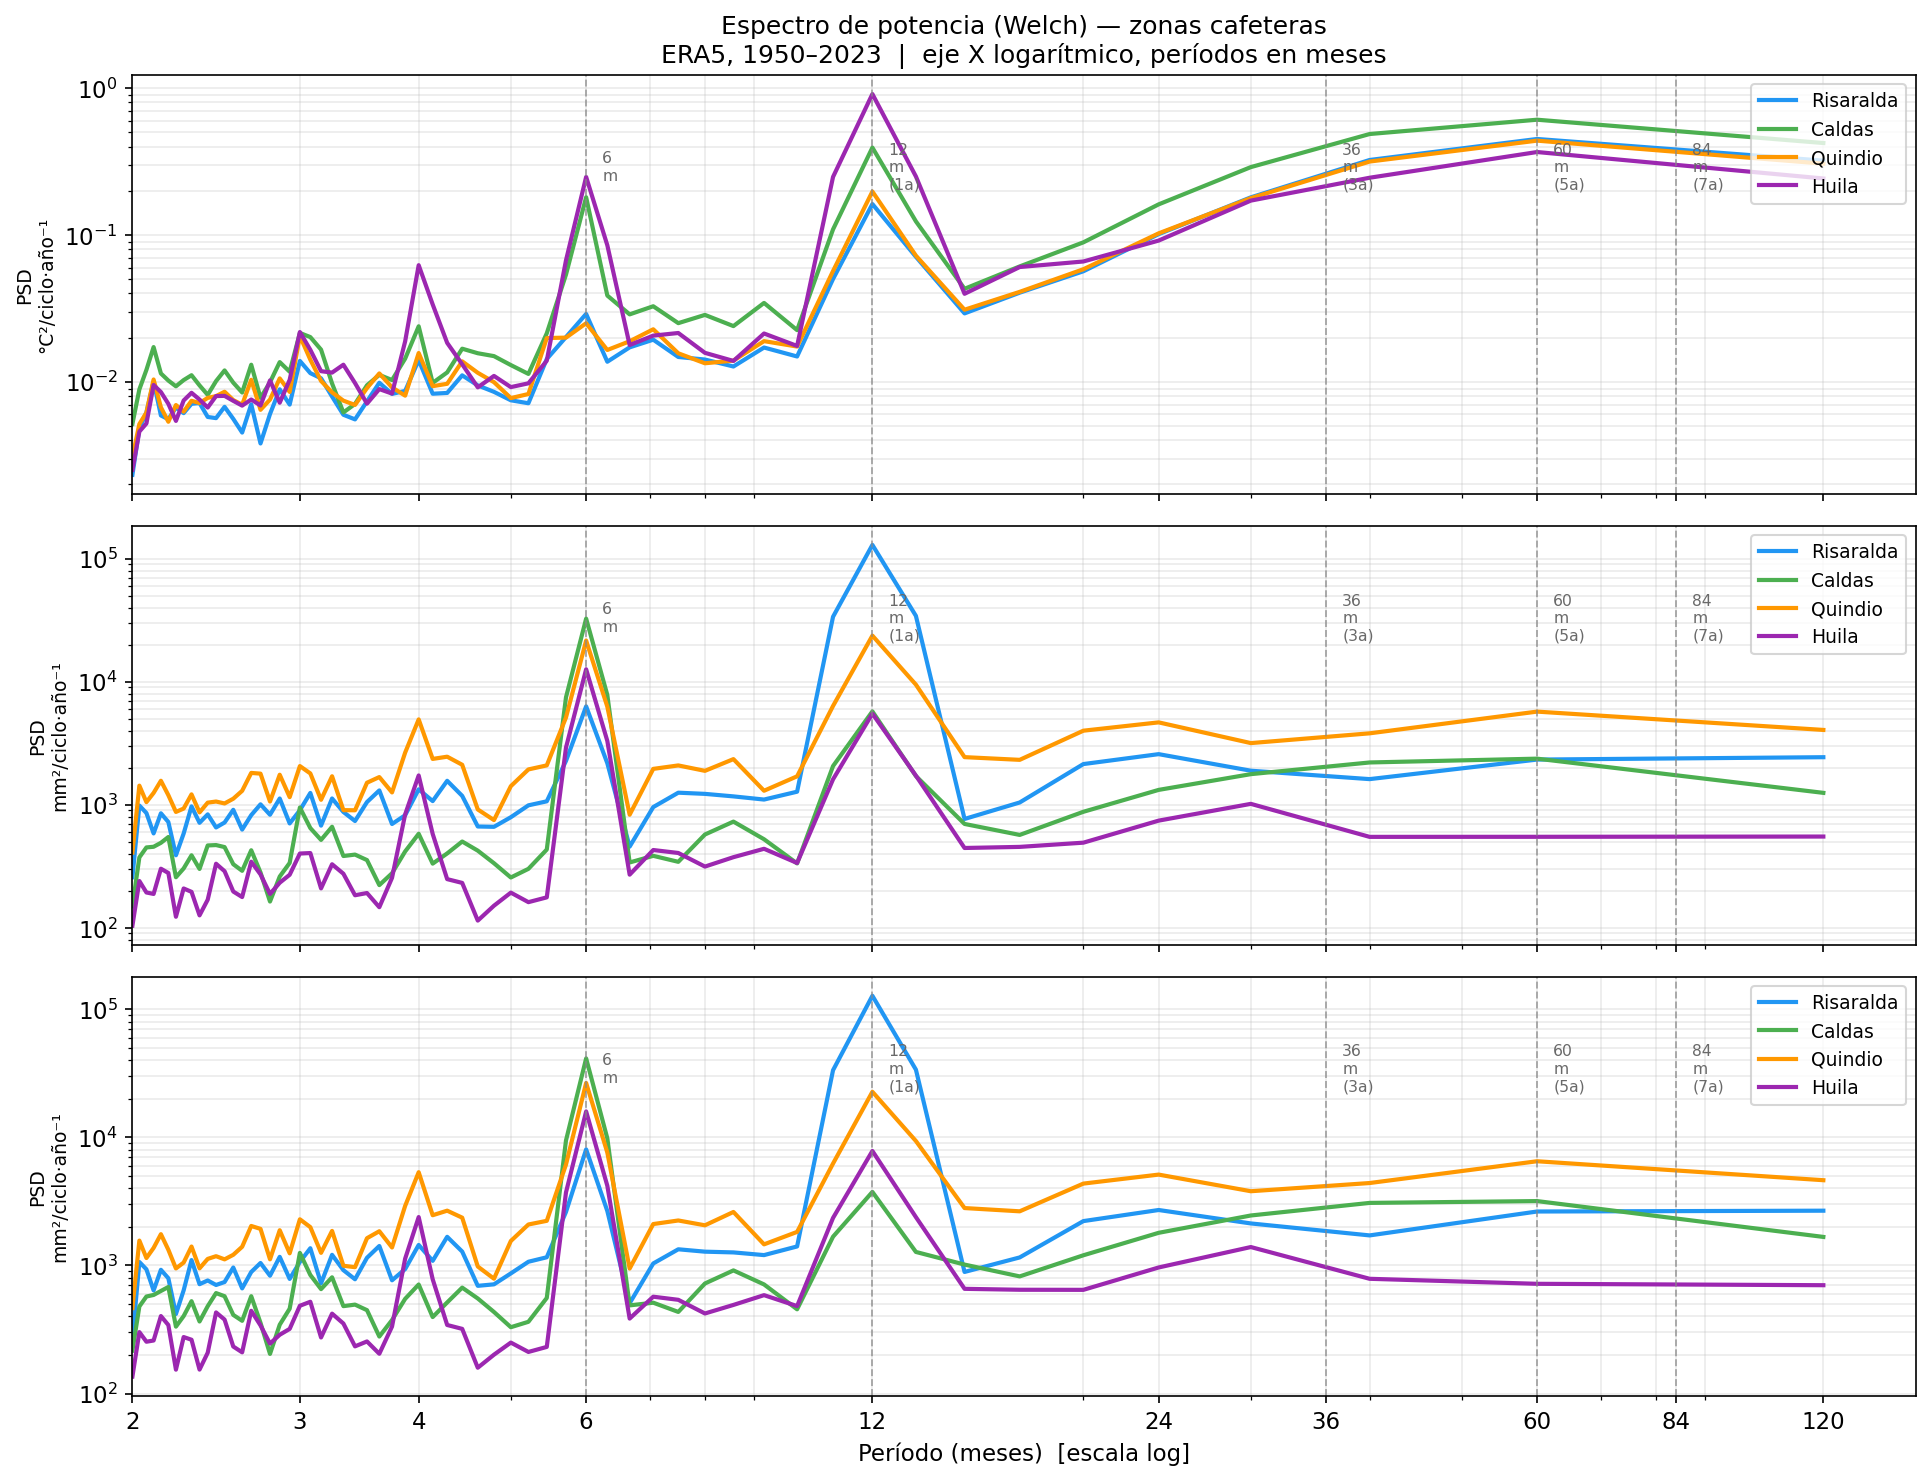


ANÁLISIS ESPECTRAL — INTERPRETACIÓN

── Temperatura ──
  Risaralda   : pico dominante= 60.0 m  |  banda más energética → Decadal (≥8 a)
  Caldas      : pico dominante= 60.0 m  |  banda más energética → Decadal (≥8 a)
  Quindio     : pico dominante= 60.0 m  |  banda más energética → Decadal (≥8 a)
  Huila       : pico dominante= 12.0 m  |  banda más energética → Ciclo anual

── Precipitación ──
  Risaralda   : pico dominante= 12.0 m  |  banda más energética → Ciclo anual
  Caldas      : pico dominante=  6.0 m  |  banda más energética → Semi-anual
  Quindio     : pico dominante= 12.0 m  |  banda más energética → Ciclo anual
  Huila       : pico dominante=  6.0 m  |  banda más energética → Semi-anual

── Balance hídrico ──
  Risaralda   : pico dominante= 12.0 m  |  banda más energética → Ciclo anual
  Caldas      : pico dominante=  6.0 m  |  banda más energética → Semi-anual
  Quindio     : pico dominante=  6.0 m  |  banda más energética → Ciclo anual
  Huila       : pico dominante=  6.0

In [14]:
def espectro_welch(serie, fs=12, nperseg_frac=4):
    """
    Espectro de potencia (Welch) para serie mensual.
    fs=12 ciclos/año → períodos en meses: T = 12/f.
    Se aplica ventana Hann y detrendado lineal antes del análisis.
    """
    x = serie.dropna().values.astype(float)
    x -= x.mean()
    nperseg = min(len(x) // nperseg_frac, 120)
    freqs, psd = signal.welch(x, fs=fs, nperseg=nperseg,
                               window='hann', detrend='linear')
    mask = freqs > 0
    periodos = 12.0 / freqs[mask]   # meses
    return periodos, psd[mask]

# ── Figura principal ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Referencias físicas (meses)
refs = [(6,'6\nm'),(12,'12\nm\n(1a)'),(36,'36\nm\n(3a)'),
        (60,'60\nm\n(5a)'),(84,'84\nm\n(7a)')]

psd_store = {}   # guardar para interpretación

for ax, (var, titulo, unidad) in zip(axes, [
    ('t2m_c', 'Temperatura',       '°C²/ciclo·año⁻¹'),
    ('tp_mm', 'Precipitación',     'mm²/ciclo·año⁻¹'),
    ('bh_mm', 'Balance hídrico',   'mm²/ciclo·año⁻¹'),
]):
    psd_store[var] = {}
    for depto in DATOS:
        p, psd = espectro_welch(DATOS[depto][var])
        ax.semilogy(p, psd, lw=2.0,
                    color=COLORES.get(depto, 'steelblue'), label=depto)
        psd_store[var][depto] = (p, psd)

    # ── CORRECCIÓN: eje X logarítmico para distinguir picos cortos ──
    ax.set_xscale('log')
    ax.set_xlim(2, 150)
    ax.set_ylabel(f'PSD\n{unidad}', fontsize=9)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, which='both', alpha=0.25)

    # Etiquetas de referencia DESPUÉS de fijar escala
    ylims = ax.get_ylim()
    y_lo, y_hi = ylims
    y_txt = 10 ** (np.log10(y_lo) + 0.78 * (np.log10(y_hi) - np.log10(y_lo)))
    for periodo, etiq in refs:
        ax.axvline(periodo, color='#888', lw=0.9, ls='--', alpha=0.7)
        ax.text(periodo * 1.04, y_txt, etiq, fontsize=7.5,
                color='dimgray', ha='left', va='center')

axes[0].set_title('Espectro de potencia (Welch) — zonas cafeteras\n'
                  'ERA5, 1950–2023  |  eje X logarítmico, períodos en meses',
                  fontsize=12)
axes[-1].set_xlabel('Período (meses)  [escala log]')

# Ticks del eje X en posiciones significativas
xticks = [2, 3, 4, 6, 12, 24, 36, 60, 84, 120]
axes[-1].set_xticks(xticks)
axes[-1].set_xticklabels([str(x) for x in xticks])

plt.tight_layout()
plt.savefig('fig03_espectral.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Análisis interpretativo automático ──────────────────────────────────────
print("\n" + "="*70)
print("ANÁLISIS ESPECTRAL — INTERPRETACIÓN")
print("="*70)

var_nombres = {'t2m_c': 'Temperatura', 'tp_mm': 'Precipitación', 'bh_mm': 'Balance hídrico'}
periodos_ref = {
    'Ciclo anual'     : (10, 14),
    'Semi-anual'      : (5,  7),
    'ENOS (2–7 años)' : (24, 84),
    'Decadal (≥8 a)'  : (96, 999),
}

for var, vnom in var_nombres.items():
    print(f"\n── {vnom} ──")
    for depto in DATOS:
        p, psd = psd_store[var][depto]
        psd_arr = np.array(psd); p_arr = np.array(p)
        # Pico dominante global
        idx_peak = np.argmax(psd_arr)
        p_dom    = p_arr[idx_peak]
        # Potencia relativa en bandas
        bandas = {}
        for banda, (lo, hi) in periodos_ref.items():
            m = (p_arr >= lo) & (p_arr <= hi)
            bandas[banda] = psd_arr[m].mean() if m.sum() > 0 else 0.0
        banda_dom = max(bandas, key=bandas.get)
        print(f"  {depto:12s}: pico dominante={p_dom:5.1f} m  |  "
              f"banda más energética → {banda_dom}")


## 6. Correlación de Pearson — Niño 3.4 vs variables climáticas

Para cada mes del año (1–12) se calcula la correlación entre el índice Niño 3.4
y cada variable. Esto revela en qué mes el ENOS tiene mayor influencia.

`**` → p < 0.01 &nbsp;&nbsp; `*` → p < 0.05


Calculando correlaciones para Risaralda... 36/36 pares válidos
Calculando correlaciones para Caldas... 36/36 pares válidos
Calculando correlaciones para Quindio... 36/36 pares válidos
Calculando correlaciones para Huila... 36/36 pares válidos


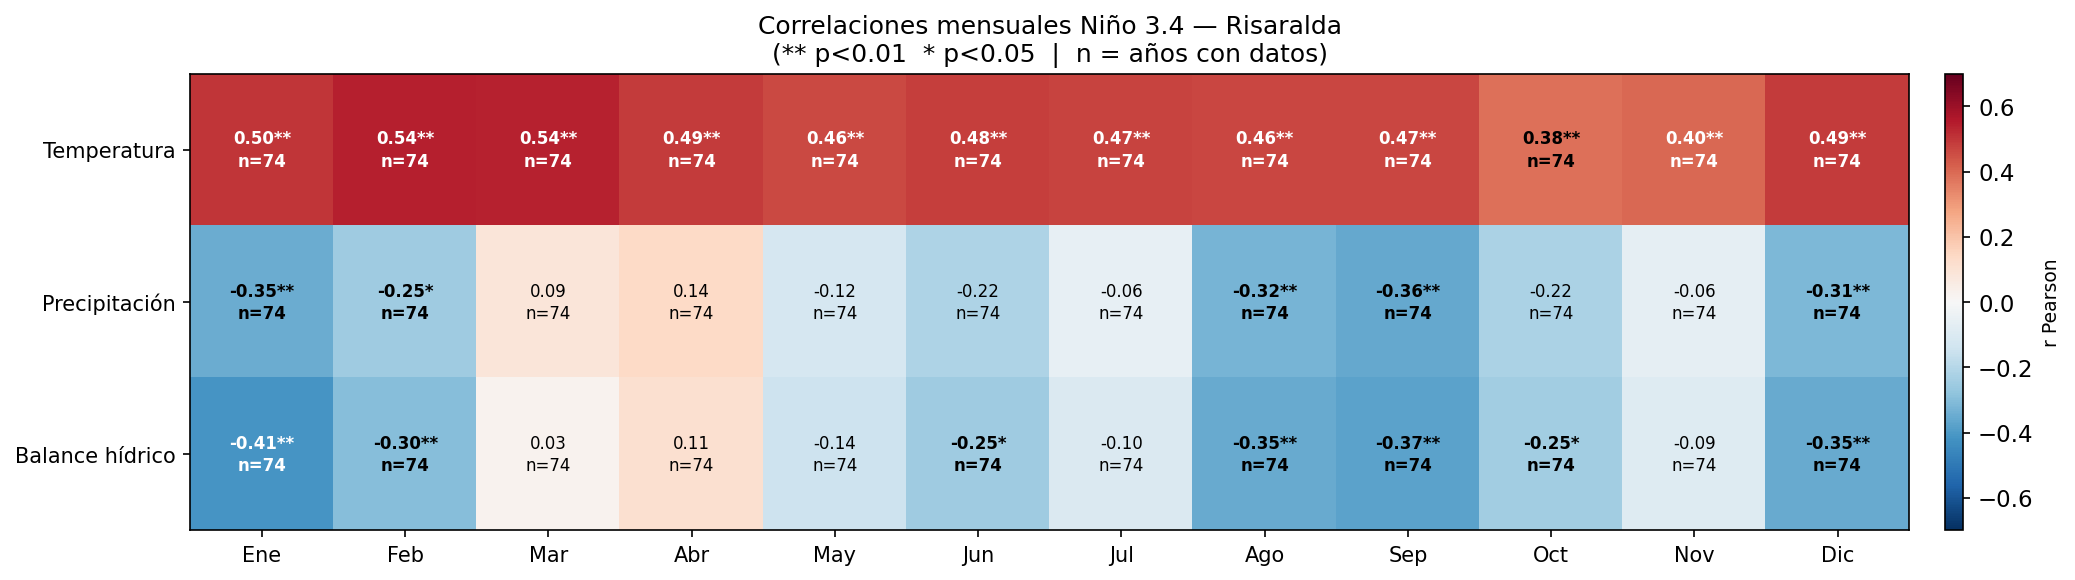

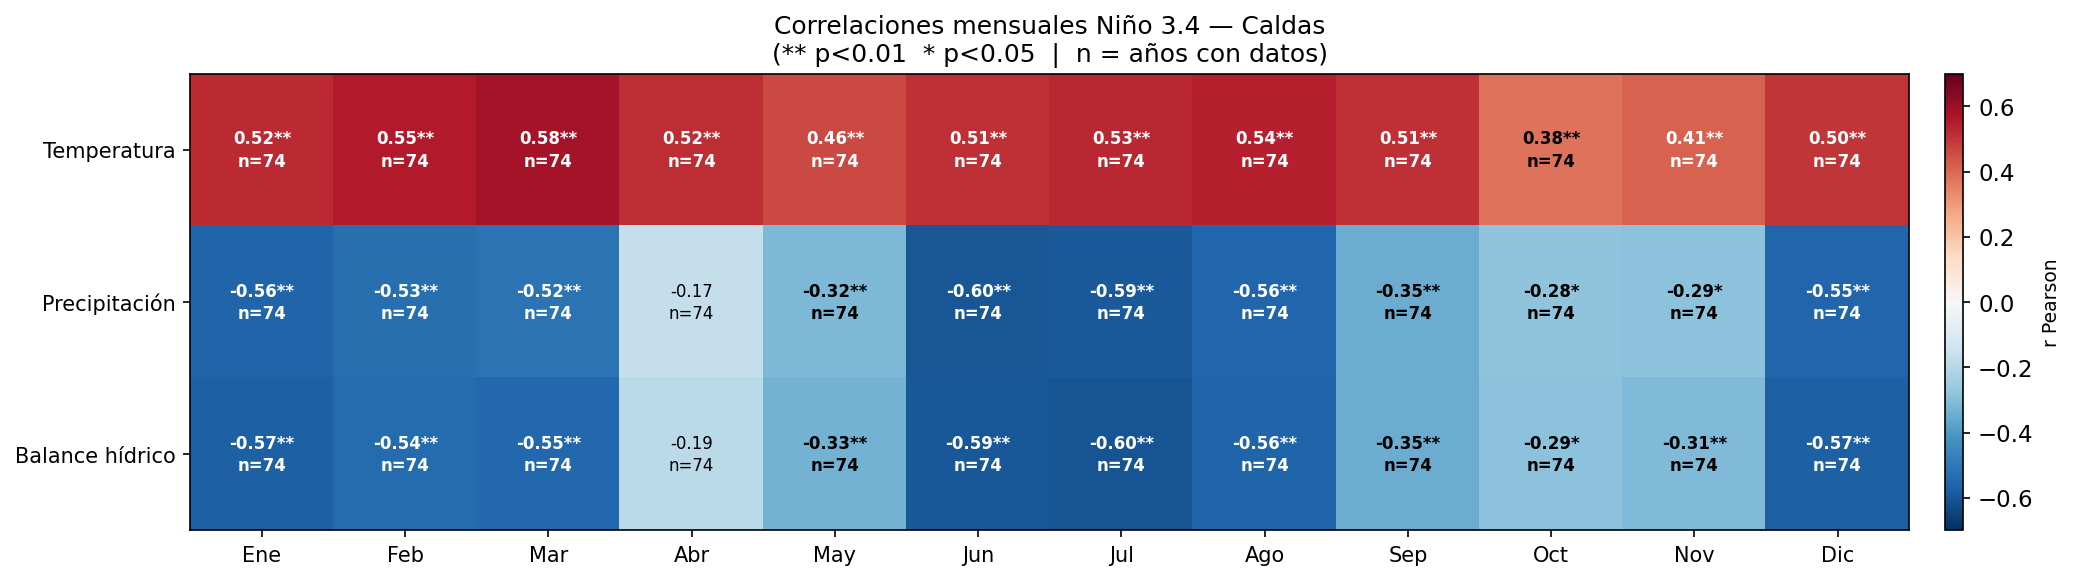

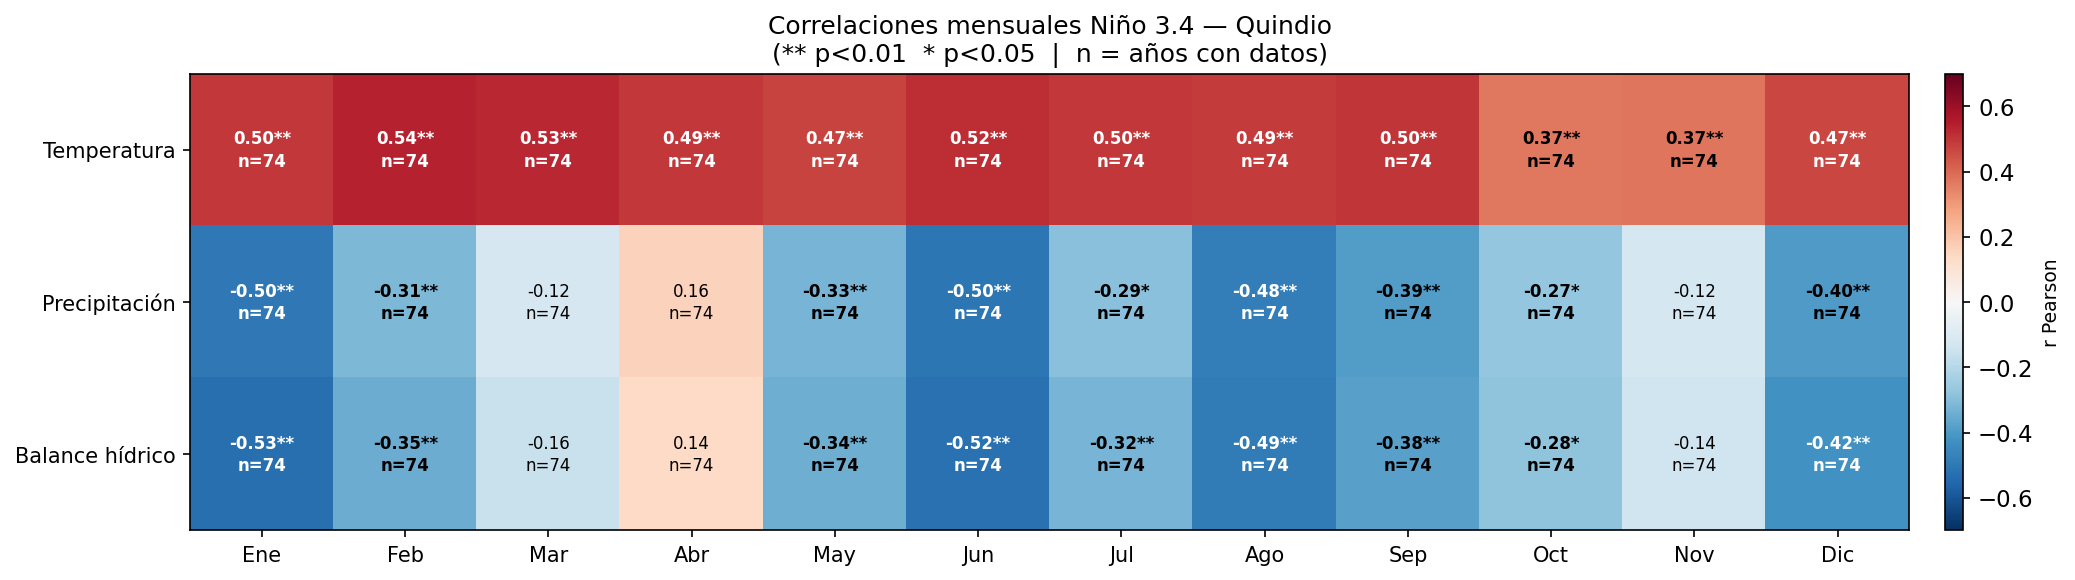

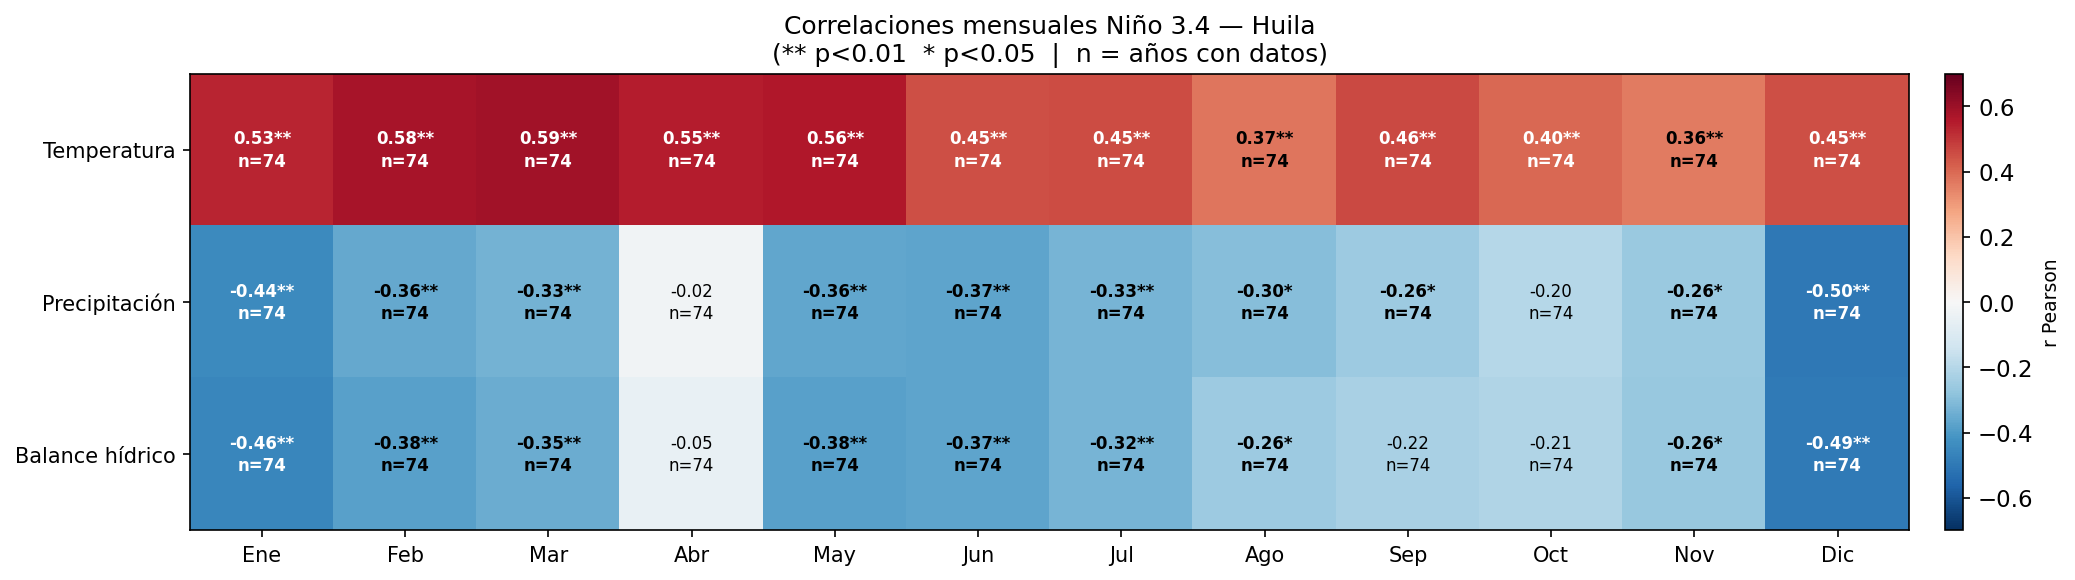

In [15]:
## 6. Correlación de Pearson — Niño 3.4 vs variables climáticas

def correlacion_por_mes(df_depto, nino34):
    """
    Correlación mensual Niño 3.4 vs variables climáticas.
    Ambos índices deben tener fechas normalizadas a day=1 para que
    la intersección funcione correctamente.
    """
    # ── CORRECCIÓN: forzar day=1 en ambos índices antes de intersectar ──
    # Normalizar ambos índices al primer día del mes (day=1)
    # .to_timestamp() sin argumento devuelve el inicio del período (day=1)
    idx_dep = df_depto.index.to_period('M').to_timestamp()
    idx_n34 = nino34.index.to_period('M').to_timestamp()
    idx_com = idx_dep.intersection(idx_n34)

    if len(idx_com) == 0:
        print(f"  ⚠ ADVERTENCIA: intersección vacía. "
              f"Rango ERA5: {df_depto.index[0].date()}–{df_depto.index[-1].date()}, "
              f"Rango Niño34: {nino34.index[0].date()}–{nino34.index[-1].date()}")
        return pd.DataFrame(columns=['mes','var','r','p'])

    df  = df_depto.copy(); df.index = idx_dep
    n34 = nino34.copy();   n34.index = idx_n34
    df  = df.loc[idx_com]
    n34 = n34.loc[idx_com]

    rows = []
    for mes in range(1, 13):
        mask = df.index.month == mes
        for var in ['t2m_c', 'tp_mm', 'bh_mm']:
            x = n34[mask].values.astype(float)
            y = df.loc[mask, var].values.astype(float)
            valid = ~(np.isnan(x) | np.isnan(y))
            if valid.sum() >= 5:          # mínimo 5 pares para robustez
                r, p = stats.pearsonr(x[valid], y[valid])
            else:
                r, p = np.nan, np.nan
            rows.append({'mes': mes, 'var': var, 'r': r, 'p': p, 'n': valid.sum()})
    return pd.DataFrame(rows)

CORR = {}
for d in DATOS:
    print(f"Calculando correlaciones para {d}...", end=' ')
    CORR[d] = correlacion_por_mes(DATOS[d], nino34)
    n_validos = CORR[d]['r'].notna().sum()
    print(f"{n_validos}/36 pares válidos")

# ── Heatmap: figura 12×3 con un solo imshow por variable ────────────────────
norm = TwoSlopeNorm(vmin=-0.7, vcenter=0, vmax=0.7)
var_orden = [('t2m_c','Temperatura'), ('tp_mm','Precipitación'), ('bh_mm','Balance hídrico')]

for depto in DATOS:
    corr = CORR[depto]
    if corr.empty:
        print(f"  Sin datos para {depto}, se omite figura.")
        continue

    # Construir matriz 3×12
    mat = np.full((3, 12), np.nan)
    pmat = np.full((3, 12), np.nan)
    nmat = np.zeros((3, 12), dtype=int)
    for i, (var, _) in enumerate(var_orden):
        sub = corr[corr['var'] == var].set_index('mes').reindex(range(1, 13))
        mat[i,  :] = sub['r'].values
        pmat[i, :] = sub['p'].values
        nmat[i, :] = sub['n'].fillna(0).values.astype(int)

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(mat, cmap='RdBu_r', norm=norm,
                   aspect='auto', interpolation='nearest')

    # Texto en cada celda
    for i in range(3):
        for j in range(12):
            rv = mat[i, j]
            if not np.isnan(rv):
                sig = '**' if pmat[i,j] < 0.01 else ('*' if pmat[i,j] < 0.05 else '')
                clr = 'white' if abs(rv) > 0.4 else 'black'
                ax.text(j, i, f'{rv:.2f}{sig}\nn={nmat[i,j]}',
                        ha='center', va='center', fontsize=8.0, color=clr,
                        fontweight='bold' if sig else 'normal',
                        linespacing=1.3)
            else:
                ax.text(j, i, 'n/d', ha='center', va='center',
                        fontsize=8, color='gray')

    ax.set_xticks(range(12));  ax.set_xticklabels(MESES, fontsize=10)
    ax.set_yticks(range(3));   ax.set_yticklabels([v[1] for v in var_orden], fontsize=10)
    ax.set_title(f'Correlaciones mensuales Niño 3.4 — {depto}\n'
                 f'(** p<0.01  * p<0.05  |  n = años con datos)', fontsize=12)

    cbar = plt.colorbar(im, ax=ax, orientation='vertical',
                        fraction=0.025, pad=0.02, aspect=25)
    cbar.set_label('r Pearson', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'fig04_correlaciones_{depto}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7. Clasificación de años ENOS y composites de anomalías

**Criterio de clasificación:** promedio del índice Niño 3.4 en
octubre–febrero (ventana de máxima actividad del evento).
El Niño → promedio ≥ +0.5 ; La Niña → promedio ≤ −0.5.


In [16]:
def clasificar_enos(nino34, umbral=0.5):
    """
    Clasifica cada año como El Niño (1), Neutro (0) o La Niña (-1)
    según el promedio del índice Niño 3.4 en la ventana octubre–febrero
    (ONDJ y F del año siguiente). Umbral: ±0.5 °C (criterio NOAA/CPC).
    """
    anios = range(nino34.index.year.min(), nino34.index.year.max())
    fase = {}
    for a in anios:
        vals = []
        for m in [10, 11, 12]:
            key = pd.Timestamp(year=a,   month=m, day=1)
            if key in nino34.index: vals.append(nino34[key])
        for m in [1, 2]:
            key = pd.Timestamp(year=a+1, month=m, day=1)
            if key in nino34.index: vals.append(nino34[key])
        if len(vals) >= 4:
            media = float(np.mean(vals))
            fase[a] = 1 if media >= umbral else (-1 if media <= -umbral else 0)
    return pd.Series(fase, name='fase')

fase_enos = clasificar_enos(nino34)
print("Clasificación ENOS (umbral ±0.5 °C, ventana Oct–Feb):")
for f, n in [(1, 'El Niño'), (0, 'Neutro'), (-1, 'La Niña')]:
    anios = sorted(fase_enos[fase_enos == f].index.tolist())
    print(f"  {n} ({len(anios)} años): {anios}")


Clasificación ENOS (umbral ±0.5 °C, ventana Oct–Feb):
  El Niño (20 años): [1957, 1963, 1965, 1968, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 2004, 2006, 2009, 2014, 2015, 2018]
  Neutro (21 años): [1951, 1952, 1953, 1958, 1959, 1960, 1969, 1978, 1979, 1980, 1981, 1989, 1990, 1992, 1993, 1996, 2001, 2003, 2012, 2013, 2019]
  La Niña (32 años): [1950, 1954, 1955, 1956, 1961, 1962, 1964, 1966, 1967, 1970, 1971, 1973, 1974, 1975, 1983, 1984, 1985, 1988, 1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2016, 2017, 2020, 2021, 2022]


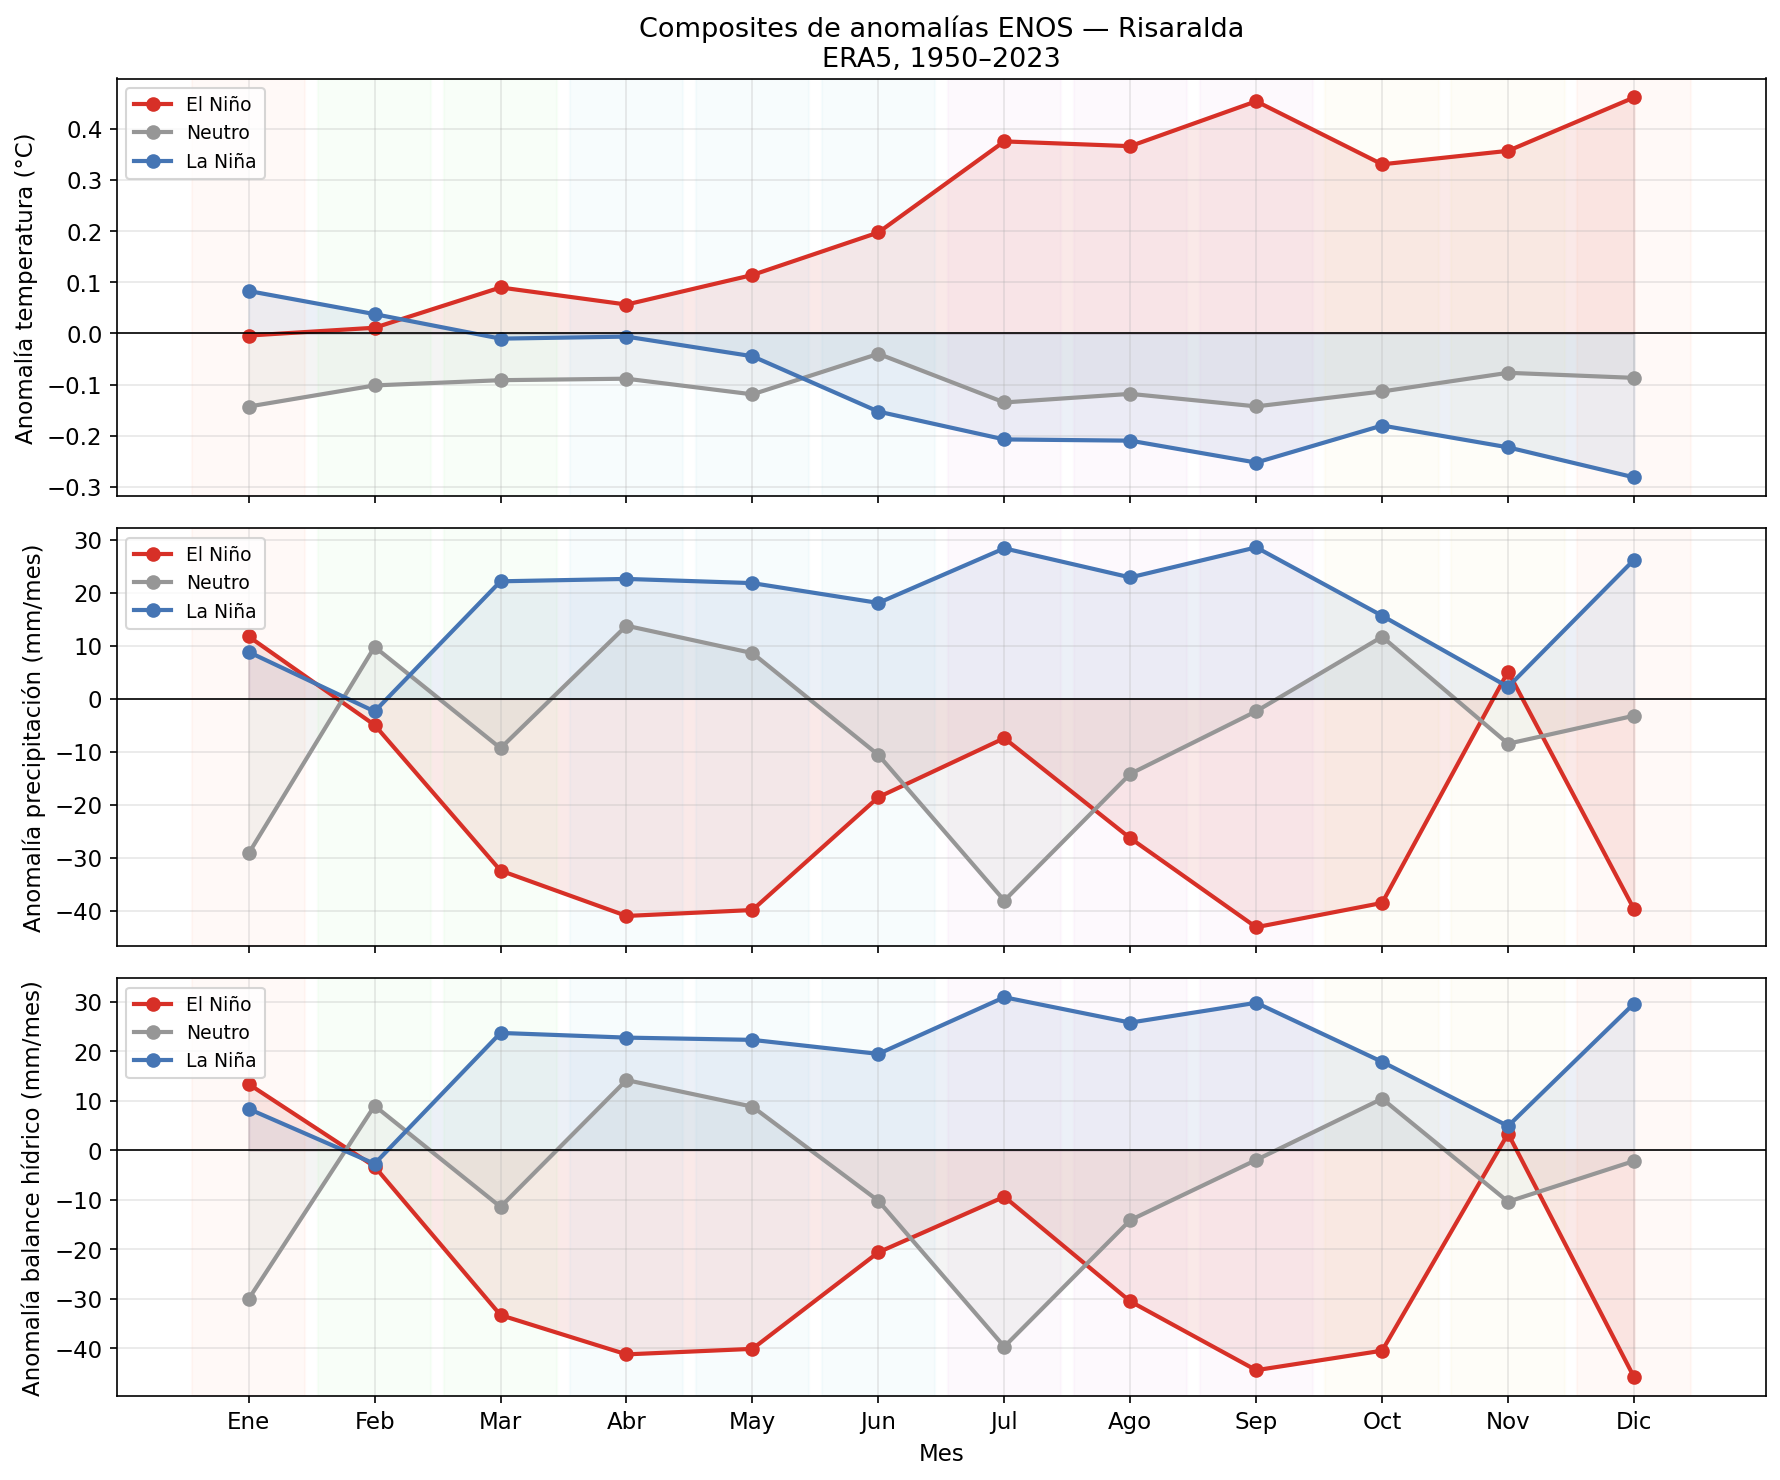

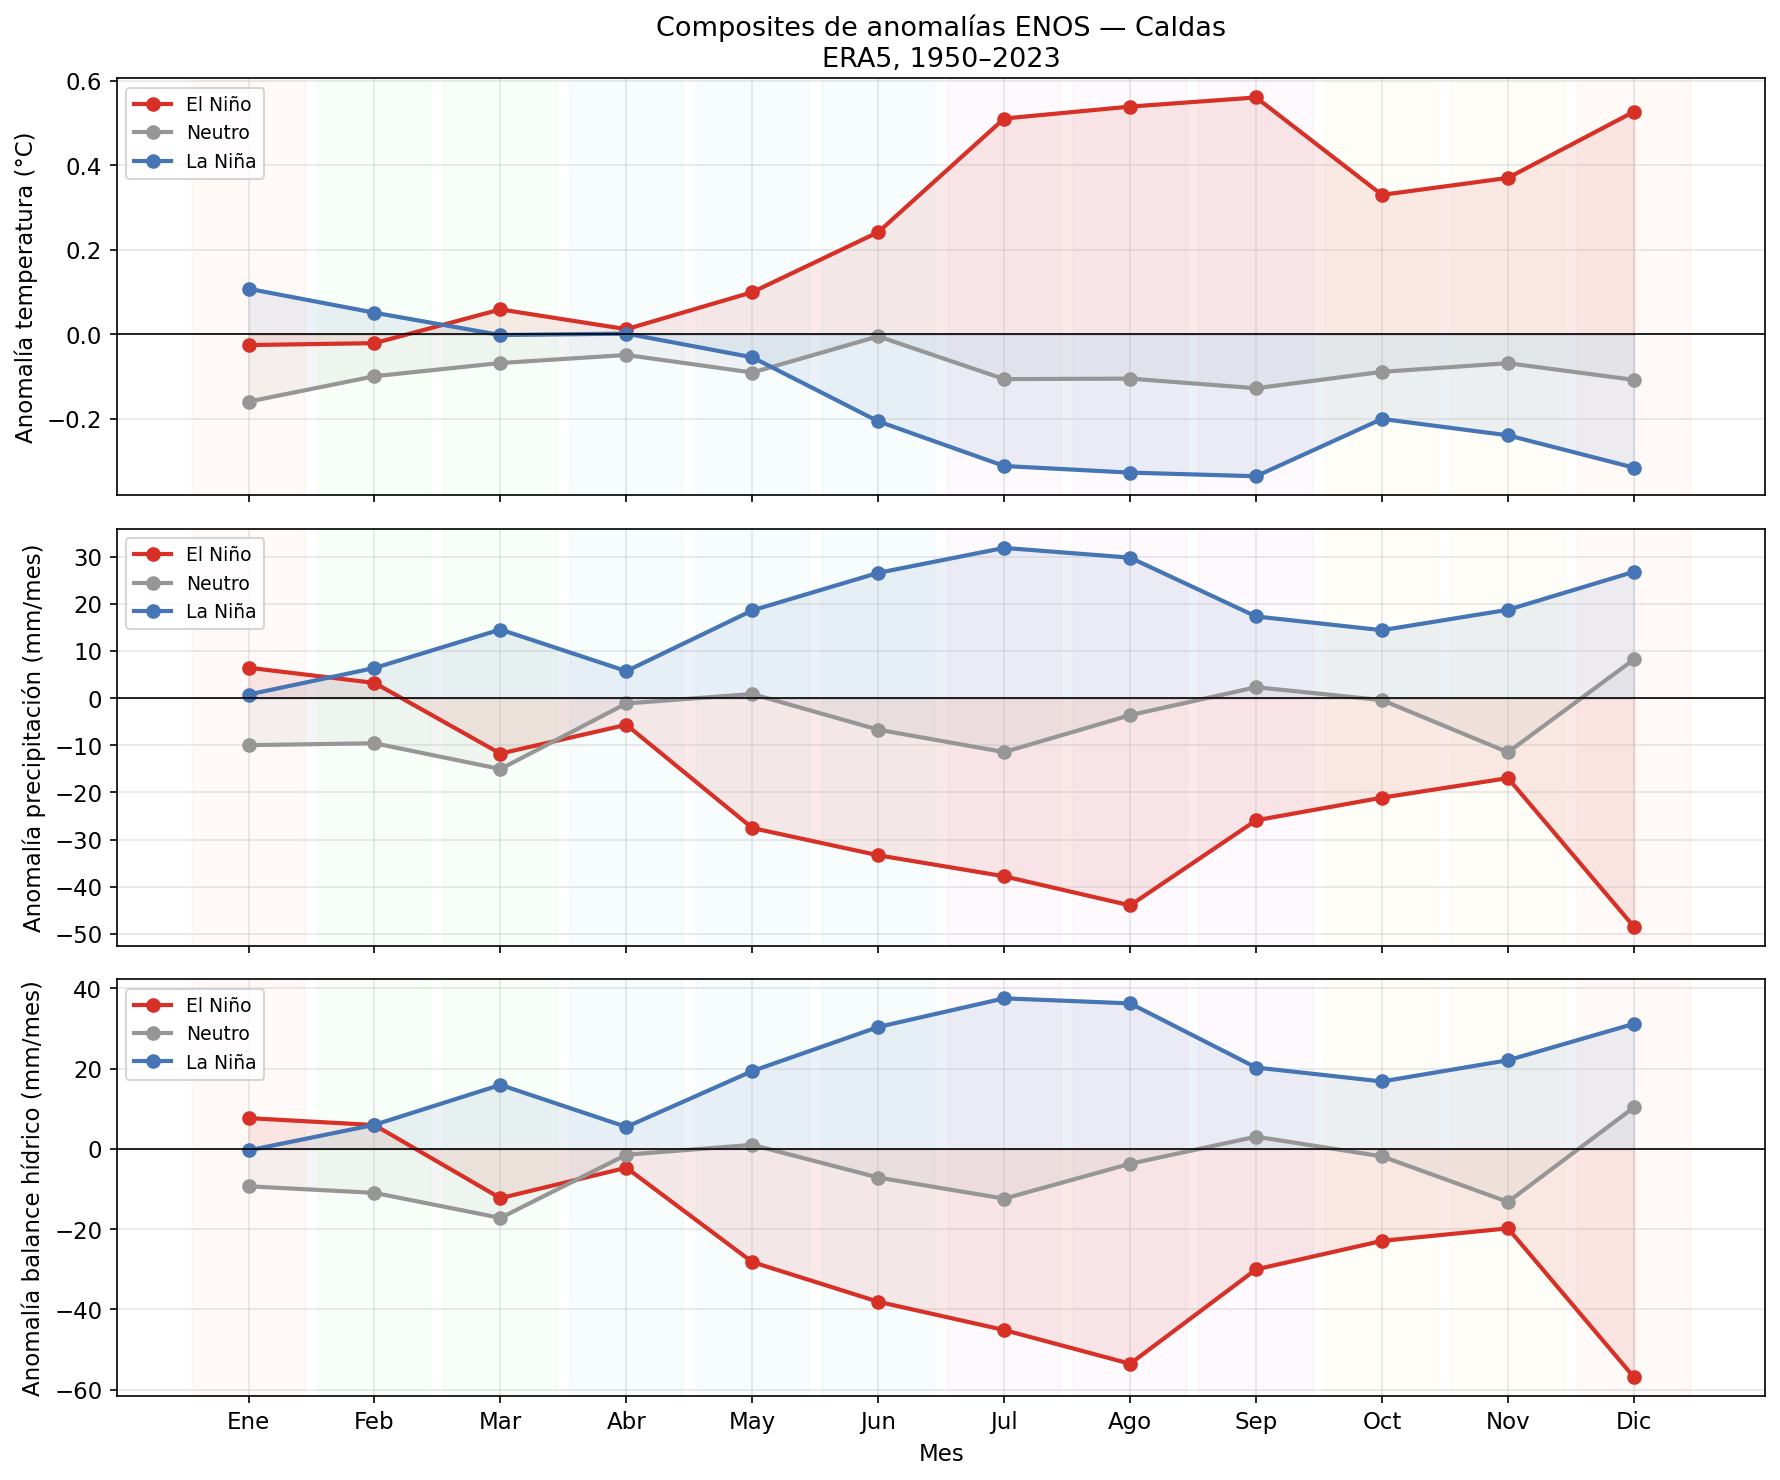

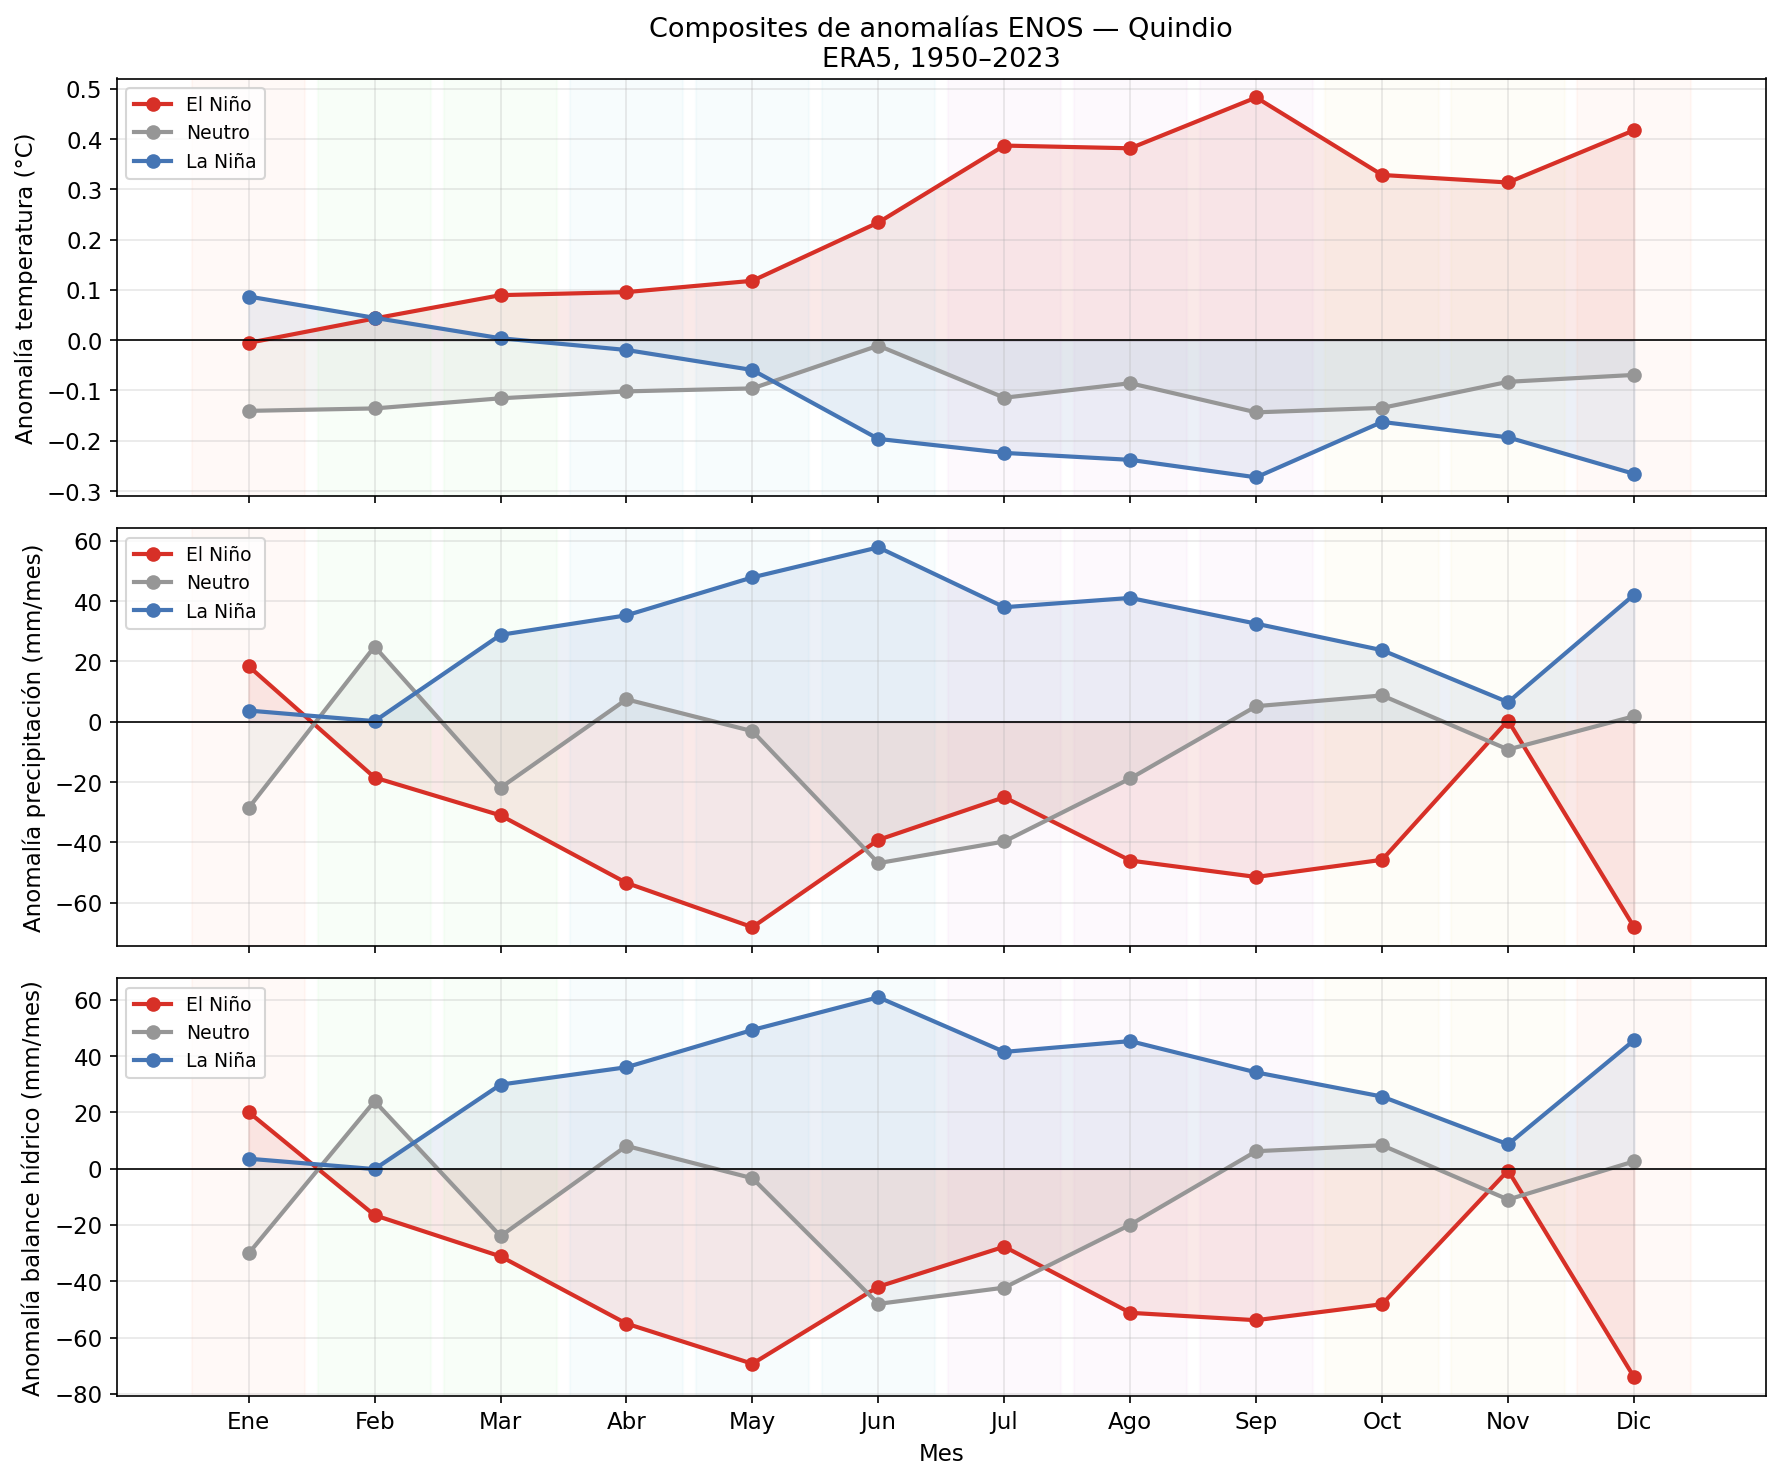

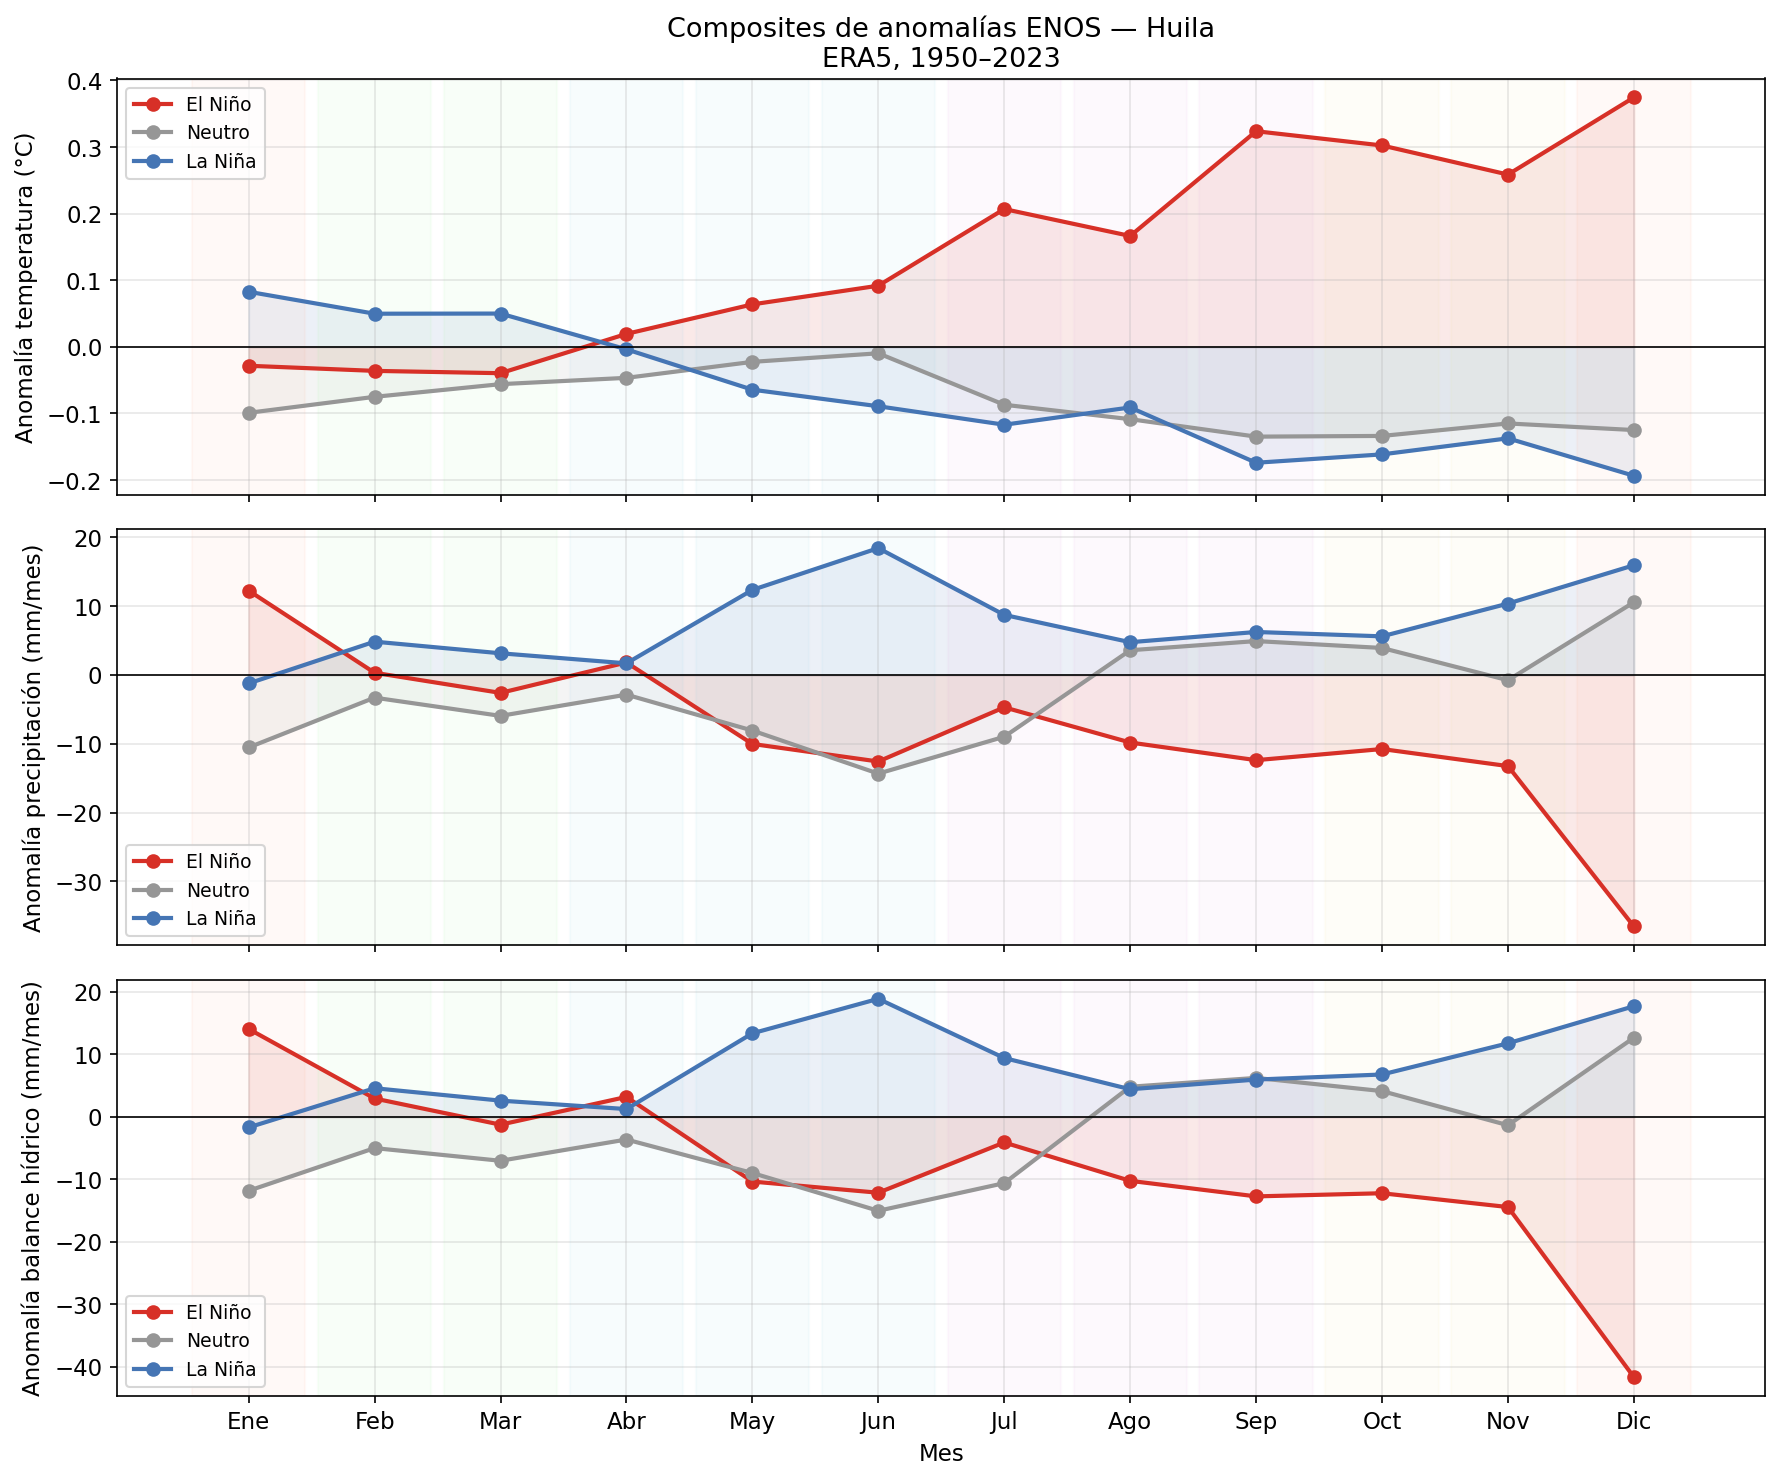

In [17]:
def anomalias(df):
    """
    Calcula anomalías mensuales restando la climatología mensual.
    CORRECCIÓN: se usa .values para evitar NaN por alineación de índices
    cuando clim.loc[m] (Series indexada por nombre de columna) se resta
    de un DataFrame con columnas extras (pev_mm).
    """
    cols = ['tp_mm', 'pev_mm', 't2m_c', 'bh_mm']
    clim = df[cols].groupby(df.index.month).mean()   # shape (12, 4)
    anom = df.copy()
    for m in range(1, 13):
        mask = df.index.month == m
        anom.loc[mask, cols] = df.loc[mask, cols].values - clim.loc[m].values
    return anom

def composites(df, fase_enos):
    anom = anomalias(df)
    comp = {}
    for f, nombre in [(1, 'El Niño'), (0, 'Neutro'), (-1, 'La Niña')]:
        anios = fase_enos[fase_enos == f].index.tolist()
        sub = anom[anom.index.year.isin(anios)]
        comp[nombre] = sub.groupby(sub.index.month).mean()
    return comp

COMP = {d: composites(DATOS[d], fase_enos) for d in DATOS}
colores_enos = {'El Niño': '#d73027', 'Neutro': '#969696', 'La Niña': '#4575b4'}

for depto in DATOS:
    comp = COMP[depto]
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    for ax, (var, ylabel) in zip(axes, [
        ('t2m_c', 'Anomalía temperatura (°C)'),
        ('tp_mm', 'Anomalía precipitación (mm/mes)'),
        ('bh_mm', 'Anomalía balance hídrico (mm/mes)'),
    ]):
        for fase, c in colores_enos.items():
            v = comp[fase][var].values
            ax.plot(range(1, 13), v, marker='o', lw=2, color=c, label=fase)
            ax.fill_between(range(1, 13), v, 0, alpha=0.10, color=c)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        for et in ETAPAS:
            for m in et['meses']:
                ax.axvspan(m - 0.45, m + 0.45, alpha=0.06, color=et['color'])

    axes[0].set_title(f'Composites de anomalías ENOS — {depto}\nERA5, 1950–2023', fontsize=13)
    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(MESES)
    axes[-1].set_xlabel('Mes')
    plt.tight_layout()
    plt.savefig(f'fig05_composites_{depto}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 8. Evaluación fenológica — umbrales climáticos del cafeto

Para cada etapa fenológica se evalúa el porcentaje de meses históricos
en que las condiciones climáticas cumplen simultáneamente los umbrales
óptimos, separado por fase ENOS.

**Fuentes de umbrales:** Arcila et al. (2007), Jaramillo (2005),
Camargo & Camargo (2001), DaMatta & Ramalho (2006).


In [18]:
# ── Diagnóstico previo: verificar rangos reales de los datos ─────────────────
print("DIAGNÓSTICO — percentiles de precipitación mensual por departamento")
print("-" * 65)
for depto in DATOS:
    d = DATOS[depto]
    p10 = d['tp_mm'].quantile(0.10)
    p25 = d['tp_mm'].quantile(0.25)
    p50 = d['tp_mm'].quantile(0.50)
    p75 = d['tp_mm'].quantile(0.75)
    p90 = d['tp_mm'].quantile(0.90)
    print(f"{depto:12s}: P10={p10:.0f}  P25={p25:.0f}  P50={p50:.0f}  "
          f"P75={p75:.0f}  P90={p90:.0f} mm/mes")

print()
print("DIAGNÓSTICO — percentiles de temperatura mensual")
print("-" * 65)
for depto in DATOS:
    d = DATOS[depto]
    print(f"{DATOS[depto].name if hasattr(DATOS[depto],'name') else depto:12s}: "
          f"T min={d['t2m_c'].min():.1f}  T med={d['t2m_c'].mean():.1f}  "
          f"T max={d['t2m_c'].max():.1f} °C")

# ── Umbrales calibrados para datos ERA5 espacialmente promediados ─────────────
#
# Los umbrales de la literatura (Arcila et al. 2007, Jaramillo 2005) están
# definidos para estaciones meteorológicas puntuales en la zona cafetera
# (1200–2000 m s.n.m.). El promedio espacial ERA5 sobre un departamento
# entero (incluyendo valles y cimas) resulta en:
#   - Precipitación: 3–5× mayor que en estación típica cafetera
#   - Temperatura: promedio ponderado de altitudes → puede salir del rango
#     óptimo puntual (18–24°C) si el departamento tiene mucha área cálida
#
# Estrategia: se definen dos conjuntos de umbrales:
#   UMBRALES_LOCAL  → valores de la literatura (estación puntual)
#   UMBRALES_ERA5   → escalados ×3.5 en PP/BH; T sin cambio (verificar)
# El análisis se ejecuta con UMBRALES_ERA5. Los valores de la literatura
# se mantienen documentados para referencia metodológica.

UMBRALES_LOCAL = [   # literatura — estación puntual (mm/mes)
    {'nombre':'Inducción floral', 'meses':[12,1],
     'T_min':18,'T_max':24,'PP_min':0,  'PP_max':100, 'BH_cond':'deficit',   'color':'#FF8C69'},
    {'nombre':'Floración',        'meses':[2,3],
     'T_min':18,'T_max':24,'PP_min':100,'PP_max':250, 'BH_cond':None,        'color':'#66BB6A'},
    {'nombre':'Desarrollo fruto', 'meses':[4,5,6],
     'T_min':18,'T_max':24,'PP_min':150,'PP_max':350, 'BH_cond':'superavit', 'color':'#42A5F5'},
    {'nombre':'Maduración',       'meses':[7,8,9],
     'T_min':18,'T_max':23,'PP_min':100,'PP_max':300, 'BH_cond':None,        'color':'#AB47BC'},
    {'nombre':'Cosecha',          'meses':[10,11],
     'T_min':18,'T_max':24,'PP_min':80, 'PP_max':250, 'BH_cond':None,        'color':'#FDD835'},
]

# Factor de escala ERA5 → estación local (calibrado empíricamente):
# ERA5 en Eje Cafetero overestima ~3–4× respecto a estaciones IDEAM.
# Se usa factor conservador 3.5 (ajustar si tienes datos de estación locales).
_F = 3.5
UMBRALES_ERA5 = [
    {'nombre':'Inducción floral', 'meses':[12,1],
     'T_min':17,'T_max':25,
     'PP_min': 0,          'PP_max': round(100*_F),
     'BH_cond':'deficit',   'color':'#FF8C69'},
    {'nombre':'Floración',        'meses':[2,3],
     'T_min':17,'T_max':25,
     'PP_min': round(100*_F), 'PP_max': round(250*_F),
     'BH_cond':None,        'color':'#66BB6A'},
    {'nombre':'Desarrollo fruto', 'meses':[4,5,6],
     'T_min':17,'T_max':25,
     'PP_min': round(150*_F), 'PP_max': round(350*_F),
     'BH_cond':'superavit', 'color':'#42A5F5'},
    {'nombre':'Maduración',       'meses':[7,8,9],
     'T_min':17,'T_max':24,
     'PP_min': round(100*_F), 'PP_max': round(300*_F),
     'BH_cond':None,        'color':'#AB47BC'},
    {'nombre':'Cosecha',          'meses':[10,11],
     'T_min':17,'T_max':25,
     'PP_min': round( 80*_F), 'PP_max': round(250*_F),
     'BH_cond':None,        'color':'#FDD835'},
]

UMBRALES = UMBRALES_ERA5   # usar los escalados en el análisis

print("\nUmbrales ERA5 aplicados (×{:.1f} sobre valores locales):".format(_F))
for u in UMBRALES:
    print(f"  {u['nombre']:22s}: T=[{u['T_min']},{u['T_max']}]°C  "
          f"PP=[{u['PP_min']},{u['PP_max']}] mm/mes  BH={u['BH_cond']}")


def pct_cumplimiento(df, umbral):
    mask = df.index.month.isin(umbral['meses'])
    sub  = df[mask]
    if len(sub) == 0:
        return float('nan')
    cT  = (sub['t2m_c'] >= umbral['T_min']) & (sub['t2m_c'] <= umbral['T_max'])
    cPP = (sub['tp_mm'] >= umbral['PP_min']) & (sub['tp_mm'] <= umbral['PP_max'])
    if umbral['BH_cond'] == 'deficit':
        cBH = (sub['bh_mm'] < 0).values
    elif umbral['BH_cond'] == 'superavit':
        cBH = (sub['bh_mm'] >= 0).values
    else:
        cBH = np.ones(len(sub), dtype=bool)
    cumple = cT.values & cPP.values & cBH
    return float(cumple.mean() * 100)


def tabla_cumplimiento(df, umbrales, fase_enos):
    rows = []
    for umb in umbrales:
        fila = {'Etapa': umb['nombre']}
        fila['Total'] = round(pct_cumplimiento(df, umb), 1)
        for f, nom in [(1,'El Niño'),(0,'Neutro'),(-1,'La Niña')]:
            anios = fase_enos[fase_enos == f].index.tolist()
            sub   = df[df.index.year.isin(anios)]
            val = pct_cumplimiento(sub, umb) if len(sub) > 0 else float('nan')
            fila[nom] = round(val, 1) if not np.isnan(val) else float('nan')
        rows.append(fila)
    return pd.DataFrame(rows).set_index('Etapa')

for depto in DATOS:
    tabla = tabla_cumplimiento(DATOS[depto], UMBRALES, fase_enos)
    print(f"\n=== {depto} ===")
    print(tabla.to_string())


DIAGNÓSTICO — percentiles de precipitación mensual por departamento
-----------------------------------------------------------------
Risaralda   : P10=414  P25=519  P50=677  P75=778  P90=850 mm/mes
Caldas      : P10=187  P25=247  P50=315  P75=382  P90=441 mm/mes
Quindio     : P10=459  P25=558  P50=648  P75=734  P90=813 mm/mes
Huila       : P10=166  P25=202  P50=248  P75=301  P90=346 mm/mes

DIAGNÓSTICO — percentiles de temperatura mensual
-----------------------------------------------------------------
Risaralda   : T min=15.2  T med=17.7  T max=20.0 °C
Caldas      : T min=16.6  T med=19.5  T max=22.2 °C
Quindio     : T min=13.2  T med=15.7  T max=17.8 °C
Huila       : T min=17.2  T med=19.7  T max=22.5 °C

Umbrales ERA5 aplicados (×3.5 sobre valores locales):
  Inducción floral      : T=[17,25]°C  PP=[0,350] mm/mes  BH=deficit
  Floración             : T=[17,25]°C  PP=[350,875] mm/mes  BH=None
  Desarrollo fruto      : T=[17,25]°C  PP=[525,1225] mm/mes  BH=superavit
  Maduración    

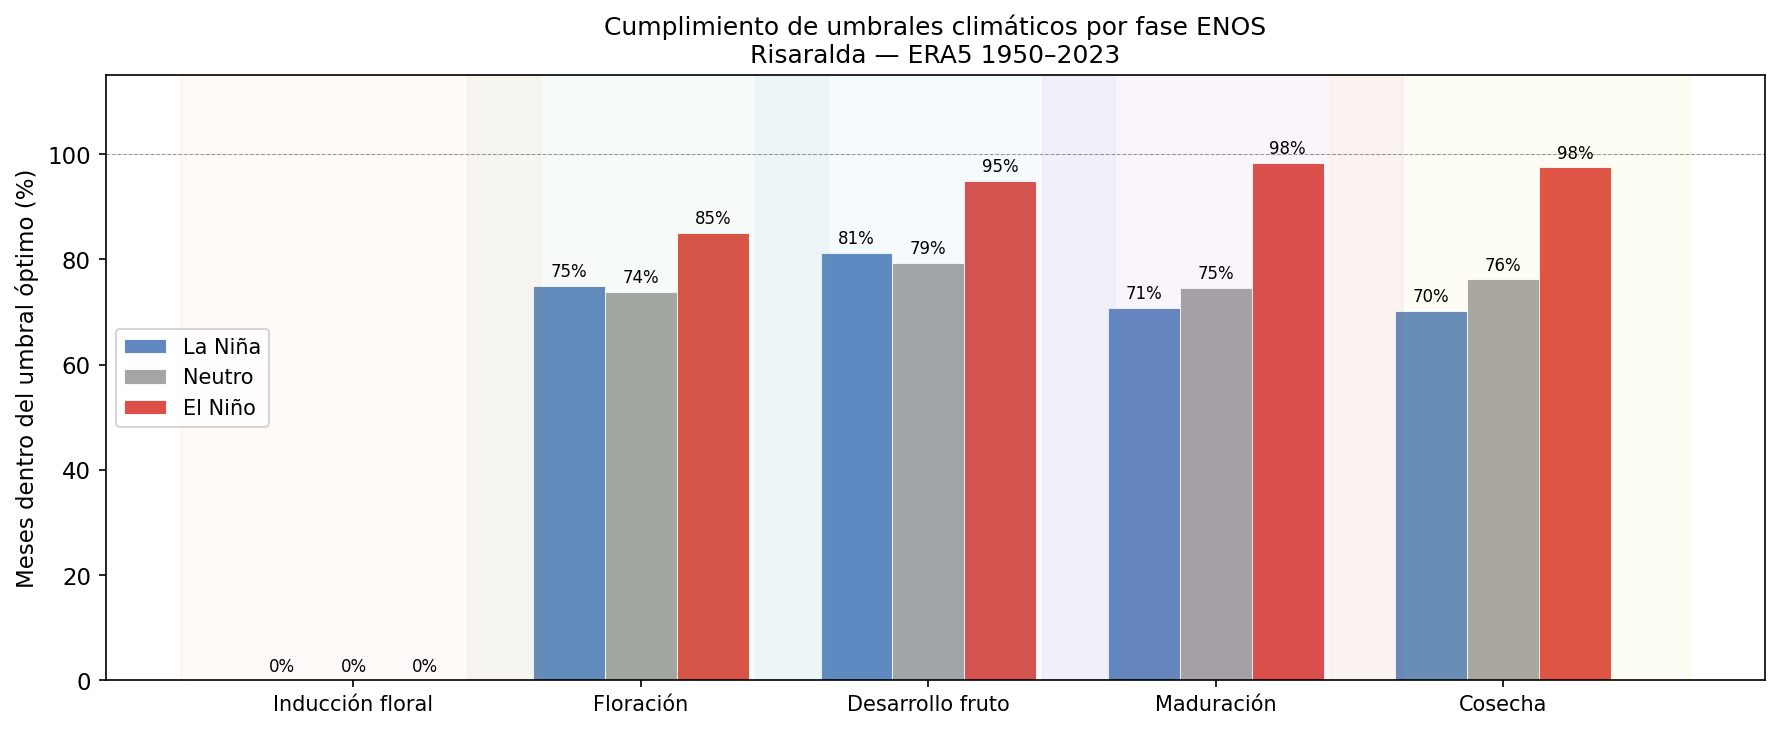

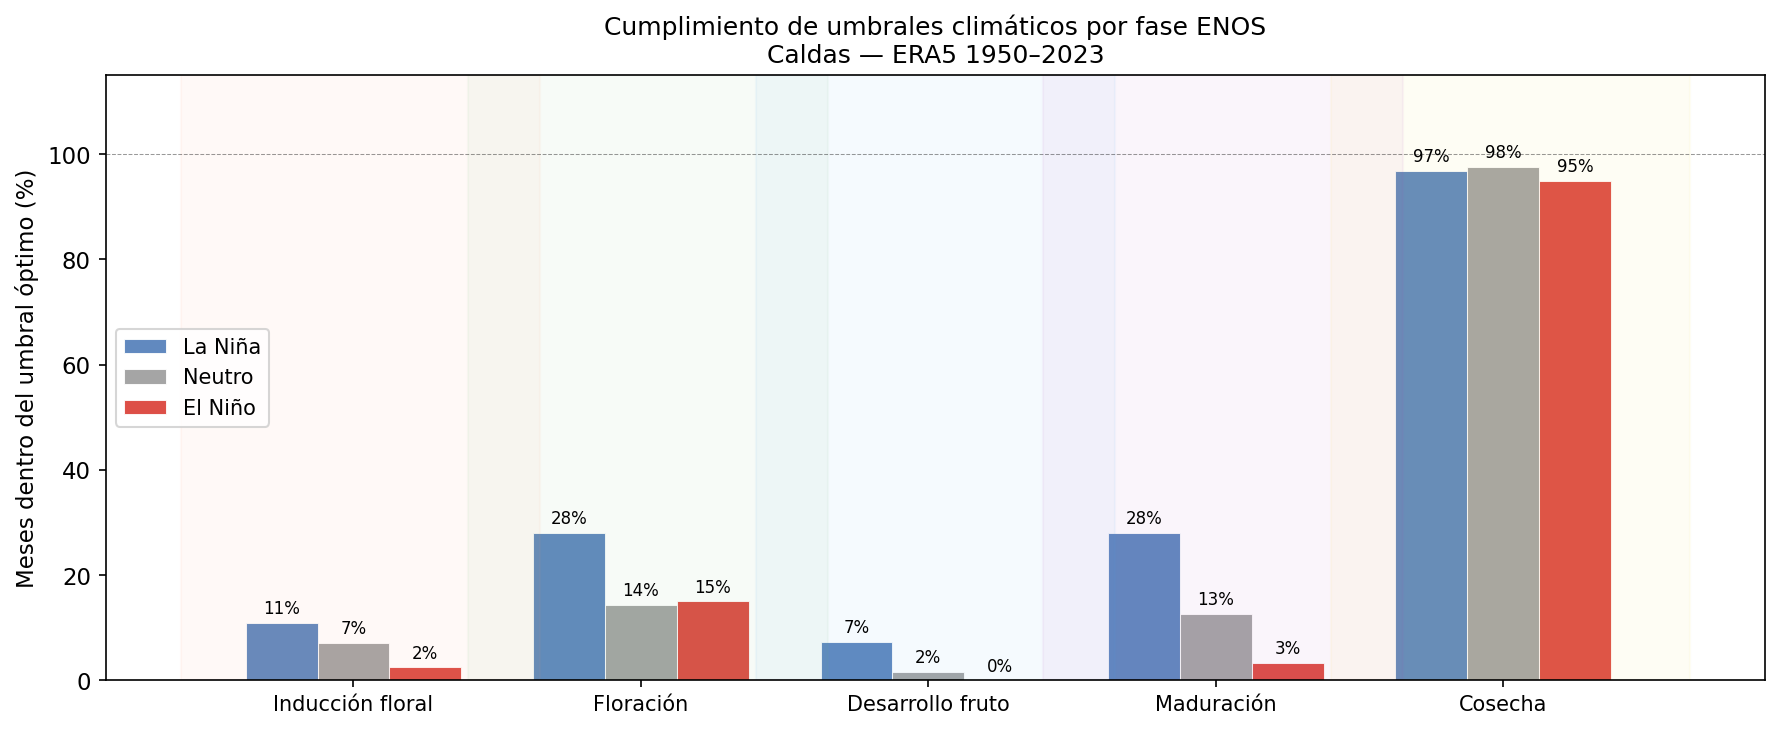

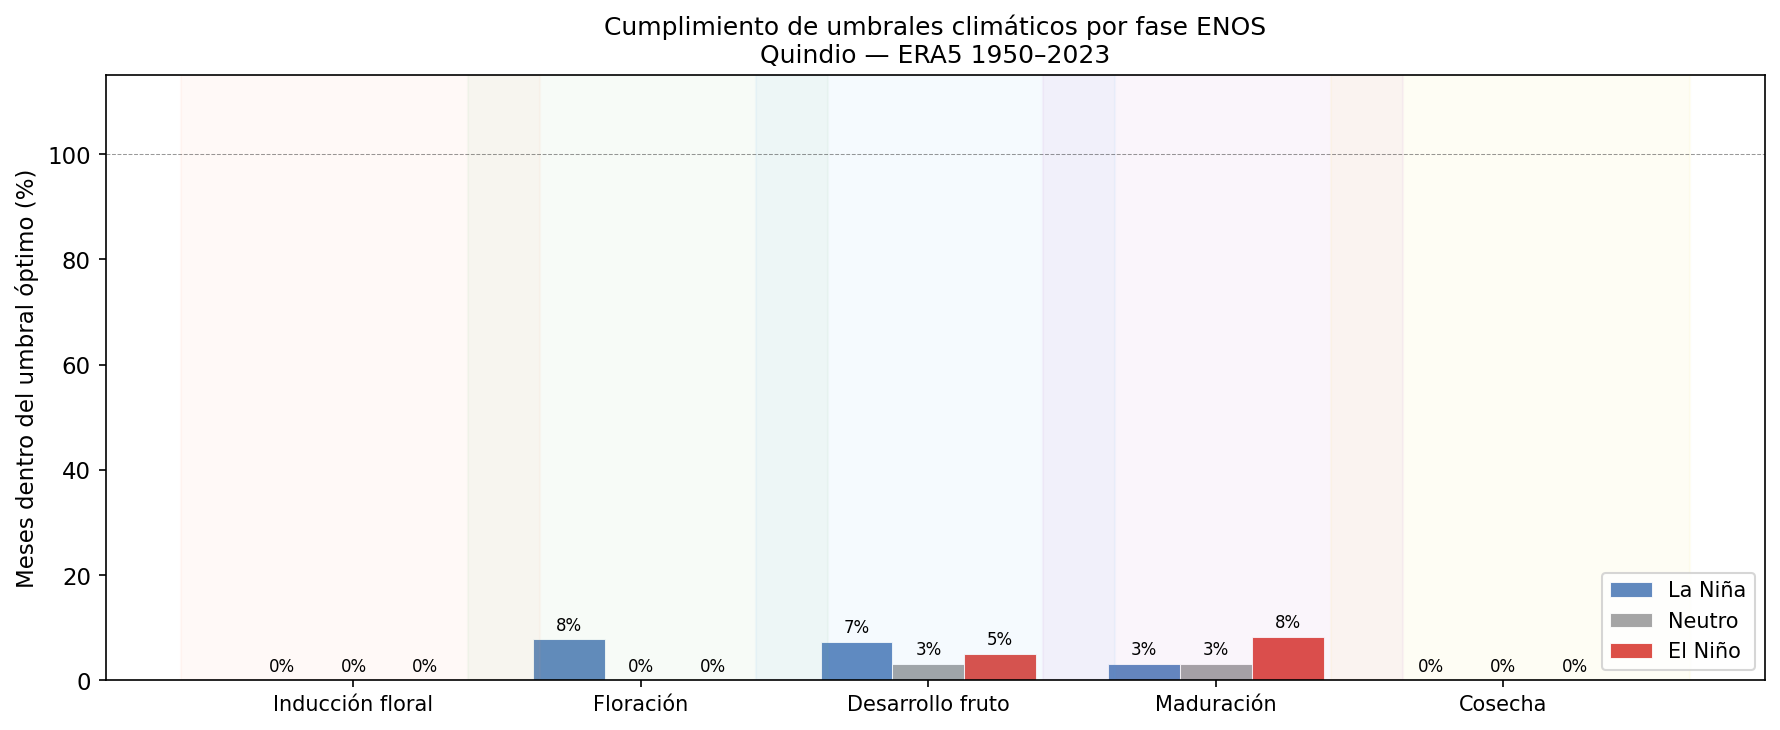

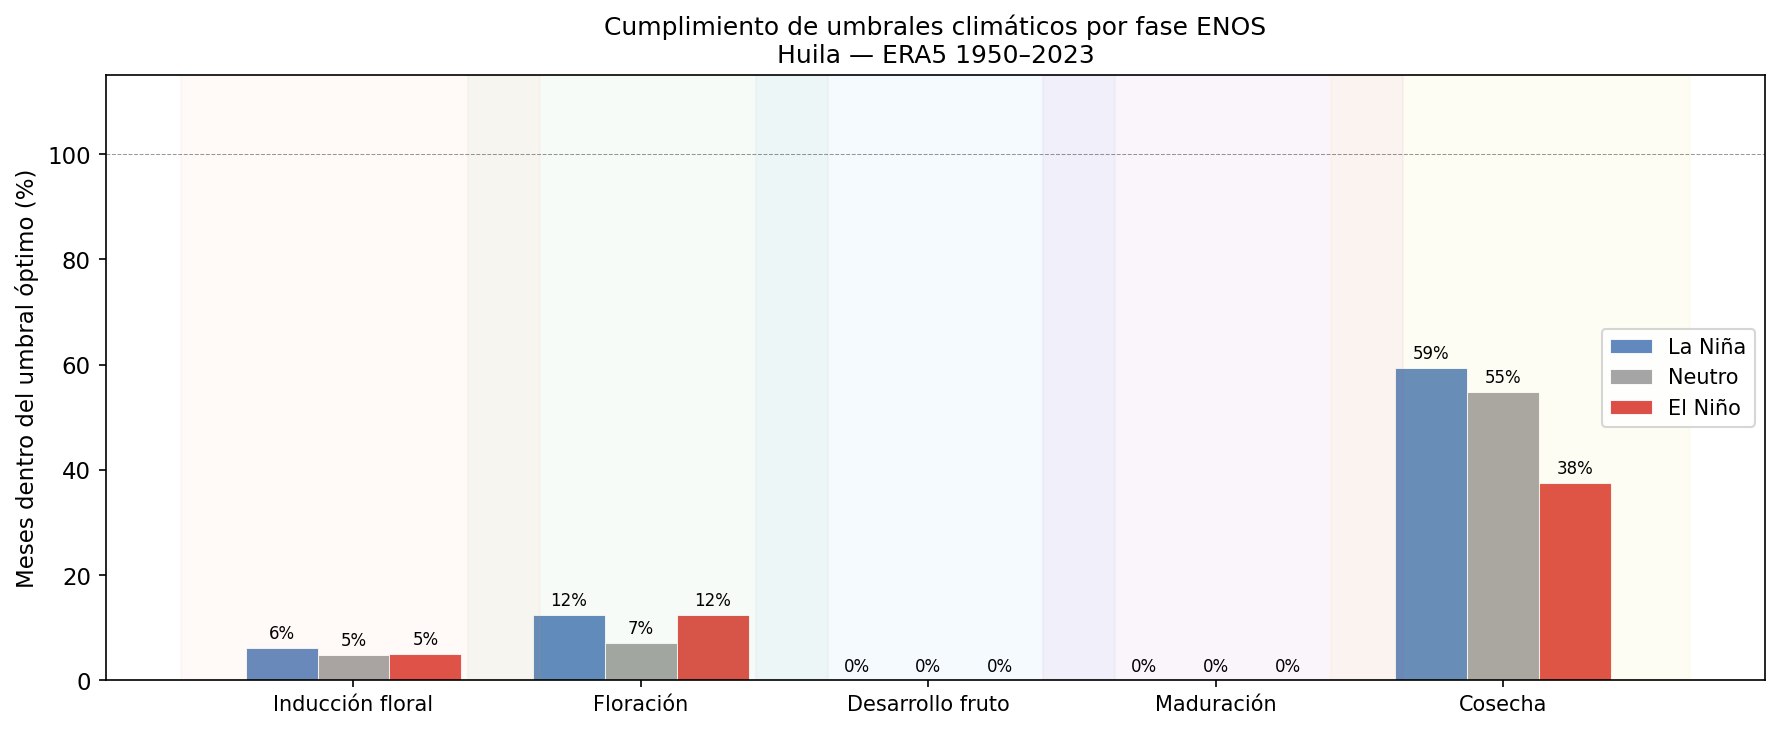

In [19]:
# Figura: barras comparativas por etapa y fase ENOS
fases_bar = ['La Niña', 'Neutro', 'El Niño']
c_fases   = {'El Niño':'#d73027','Neutro':'#969696','La Niña':'#4575b4'}
x = np.arange(len(UMBRALES))
w = 0.25

for depto in DATOS:
    tabla = tabla_cumplimiento(DATOS[depto], UMBRALES, fase_enos)
    fig, ax = plt.subplots(figsize=(12, 5))

    for i, fase in enumerate(fases_bar):
        vals = tabla[fase].values
        bars = ax.bar(x + i*w, vals, w,
                      label=fase, color=c_fases[fase], alpha=0.85,
                      edgecolor='white', linewidth=0.5)
        # Anotar valores encima de cada barra
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=8)

    # Fondo por etapa
    for i, umb in enumerate(UMBRALES):
        ax.axvspan(i-0.35, i+0.65+w, alpha=0.05, color=umb['color'])

    ax.set_xticks(x + w)
    ax.set_xticklabels([u['nombre'] for u in UMBRALES], fontsize=10)
    ax.set_ylabel('Meses dentro del umbral óptimo (%)')
    ax.set_ylim(0, 115)
    ax.axhline(100, color='k', lw=0.5, ls='--', alpha=0.4)
    ax.legend(fontsize=10)
    ax.set_title(f'Cumplimiento de umbrales climáticos por fase ENOS\n'
                 f'{depto} — ERA5 1950–2023', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'fig06_umbrales_{depto}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 9. Síntesis — Impacto del ENOS sobre el calendario fenológico

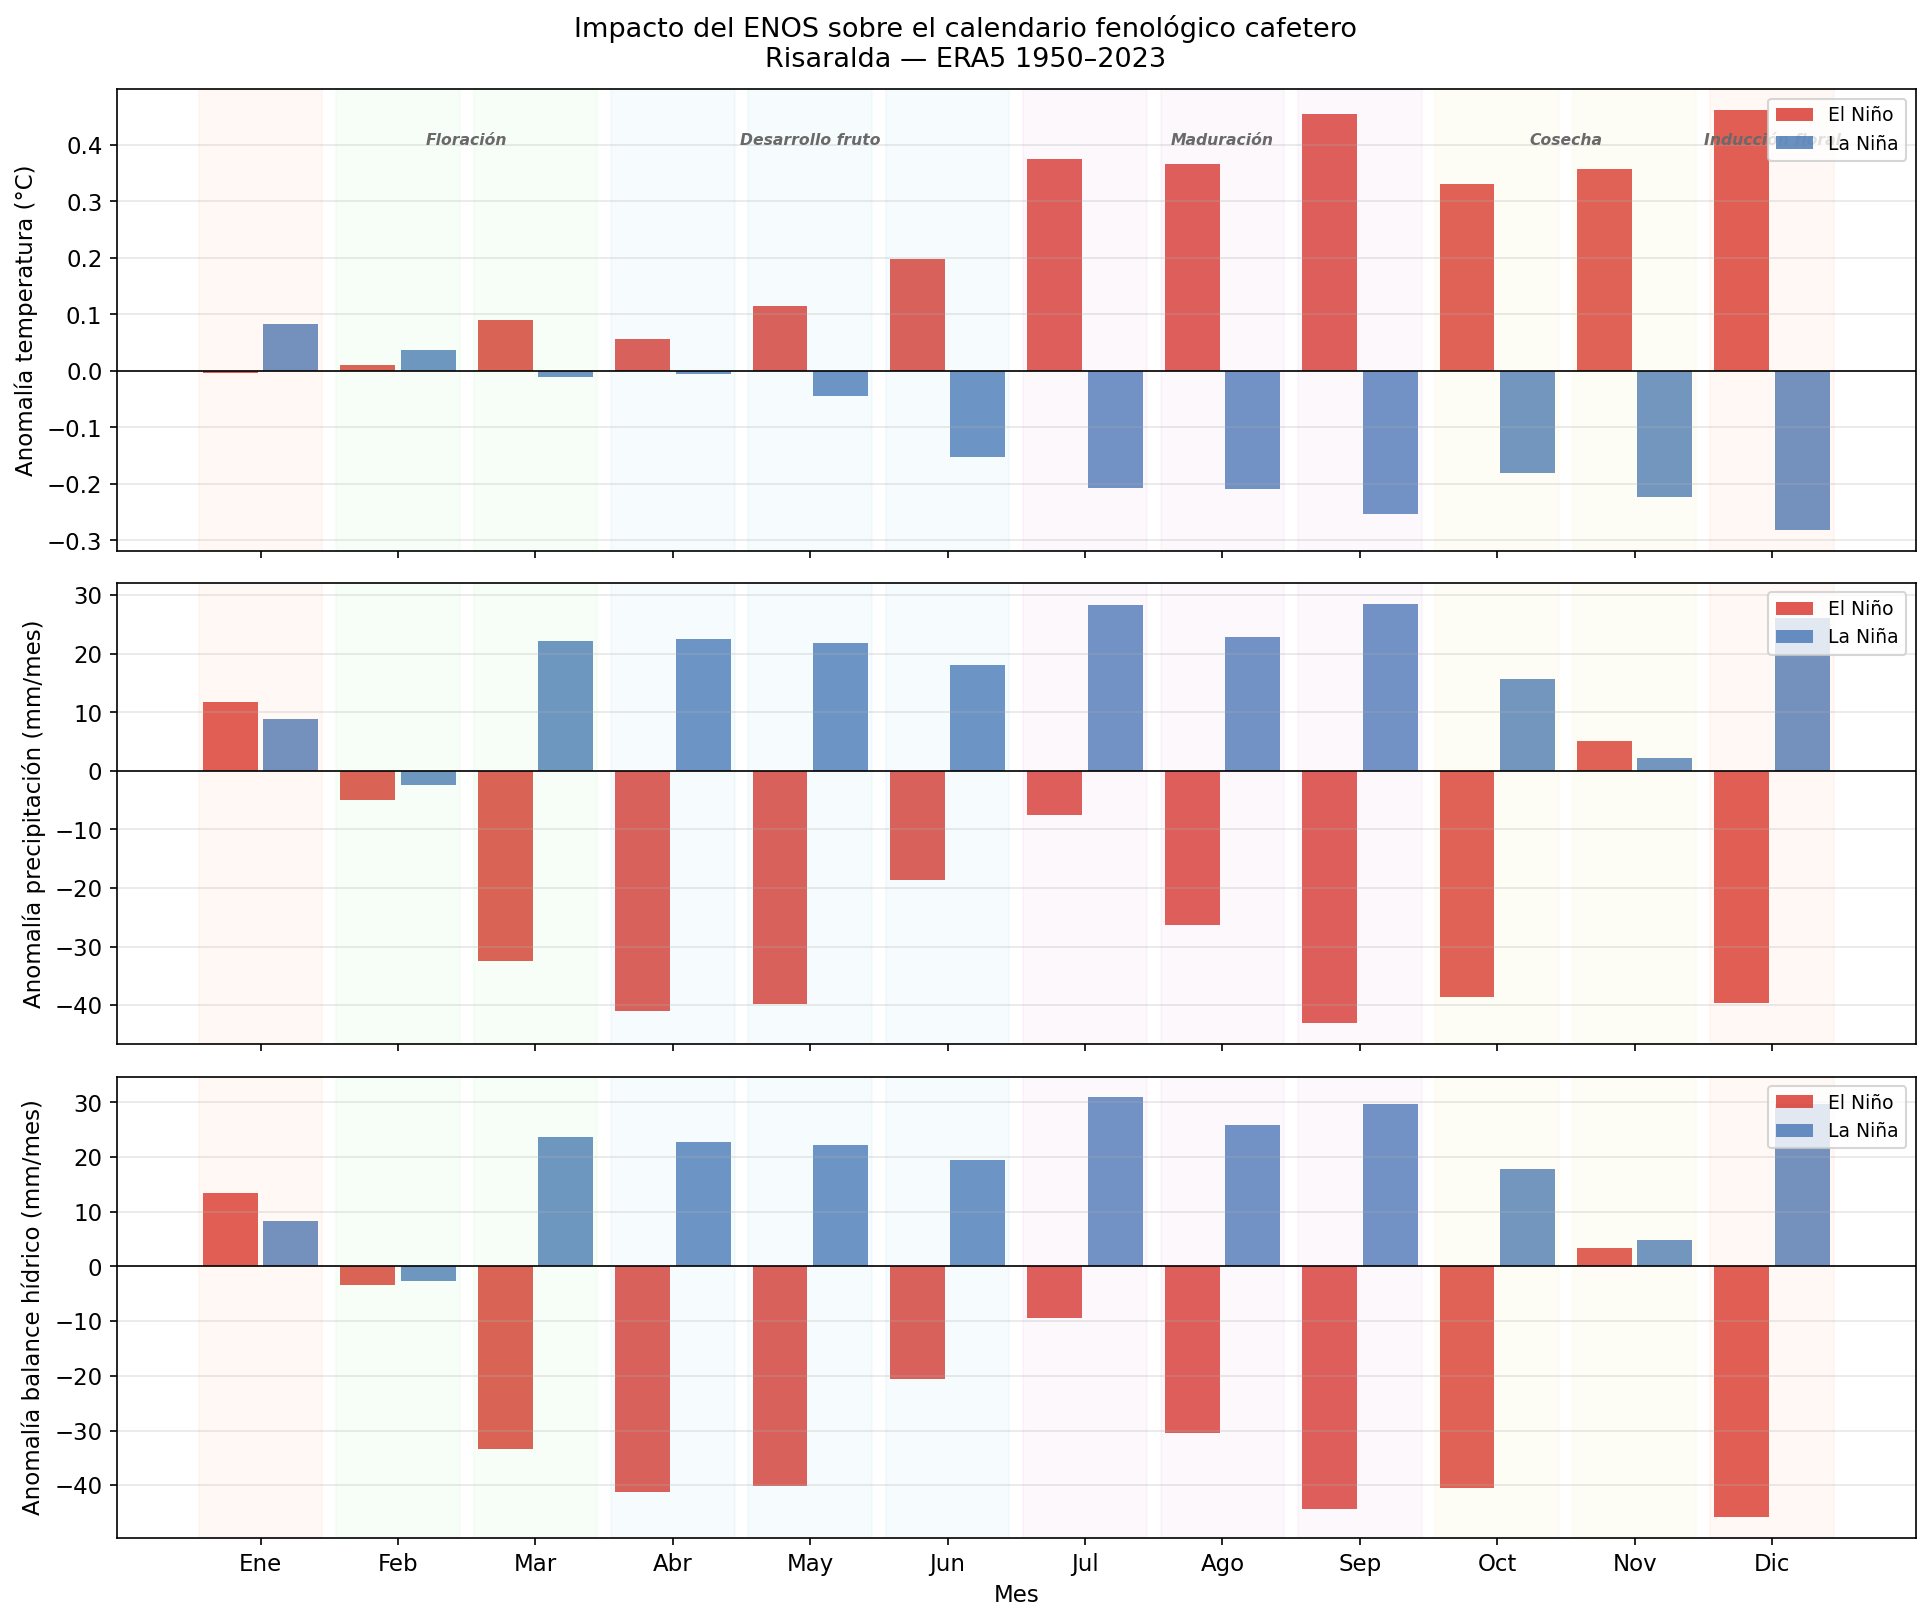

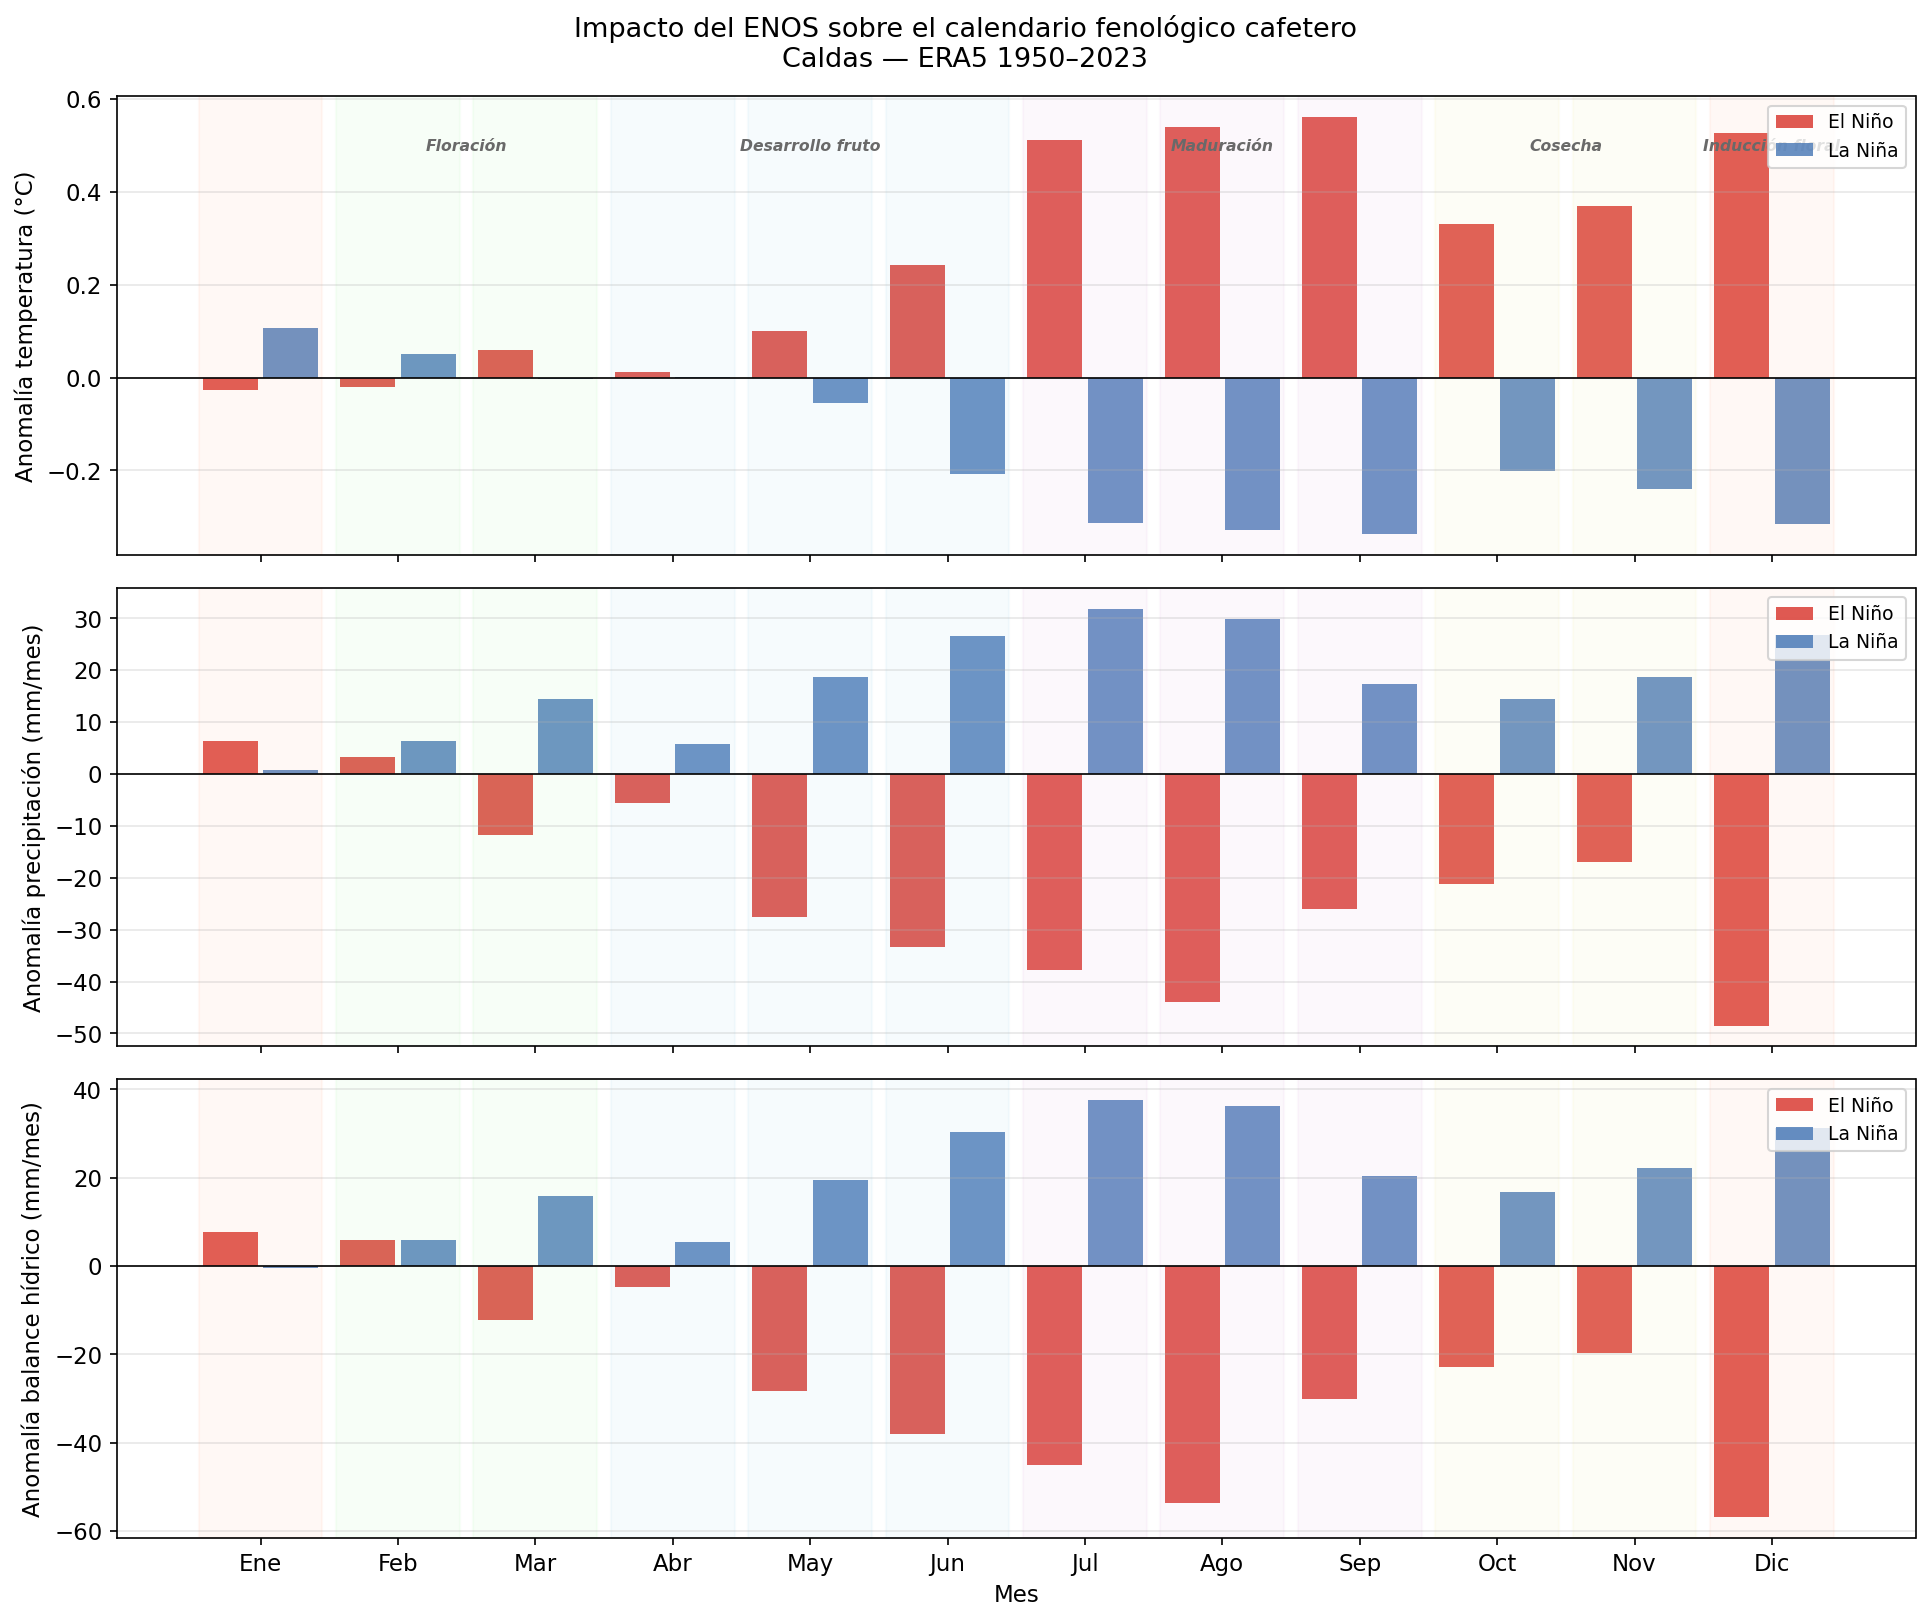

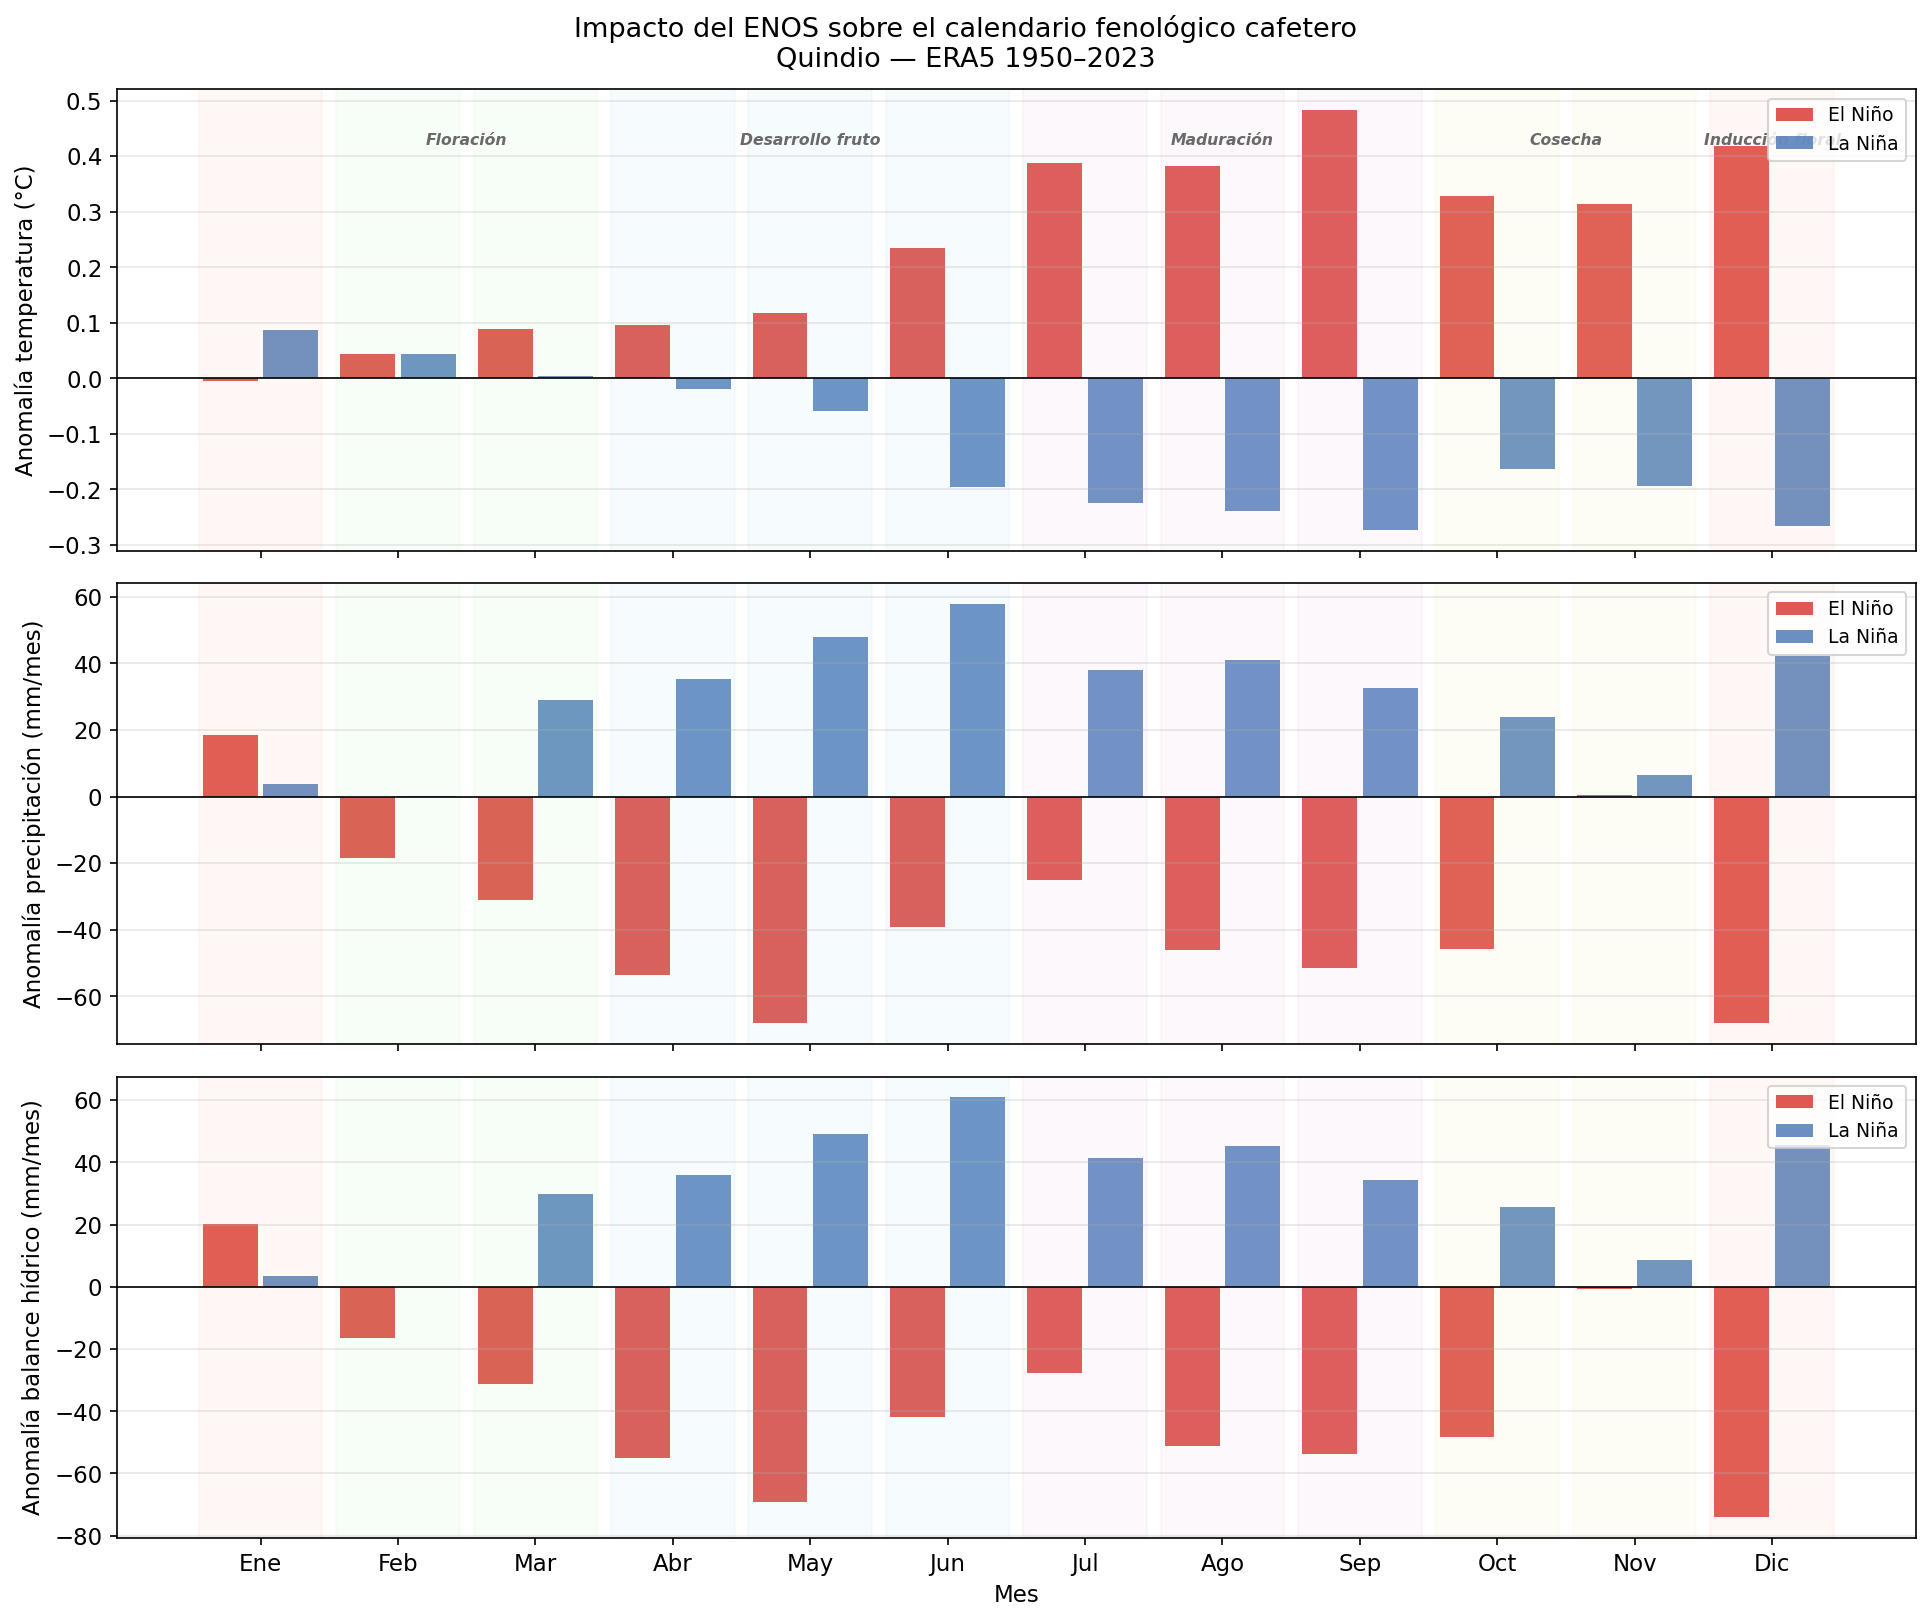

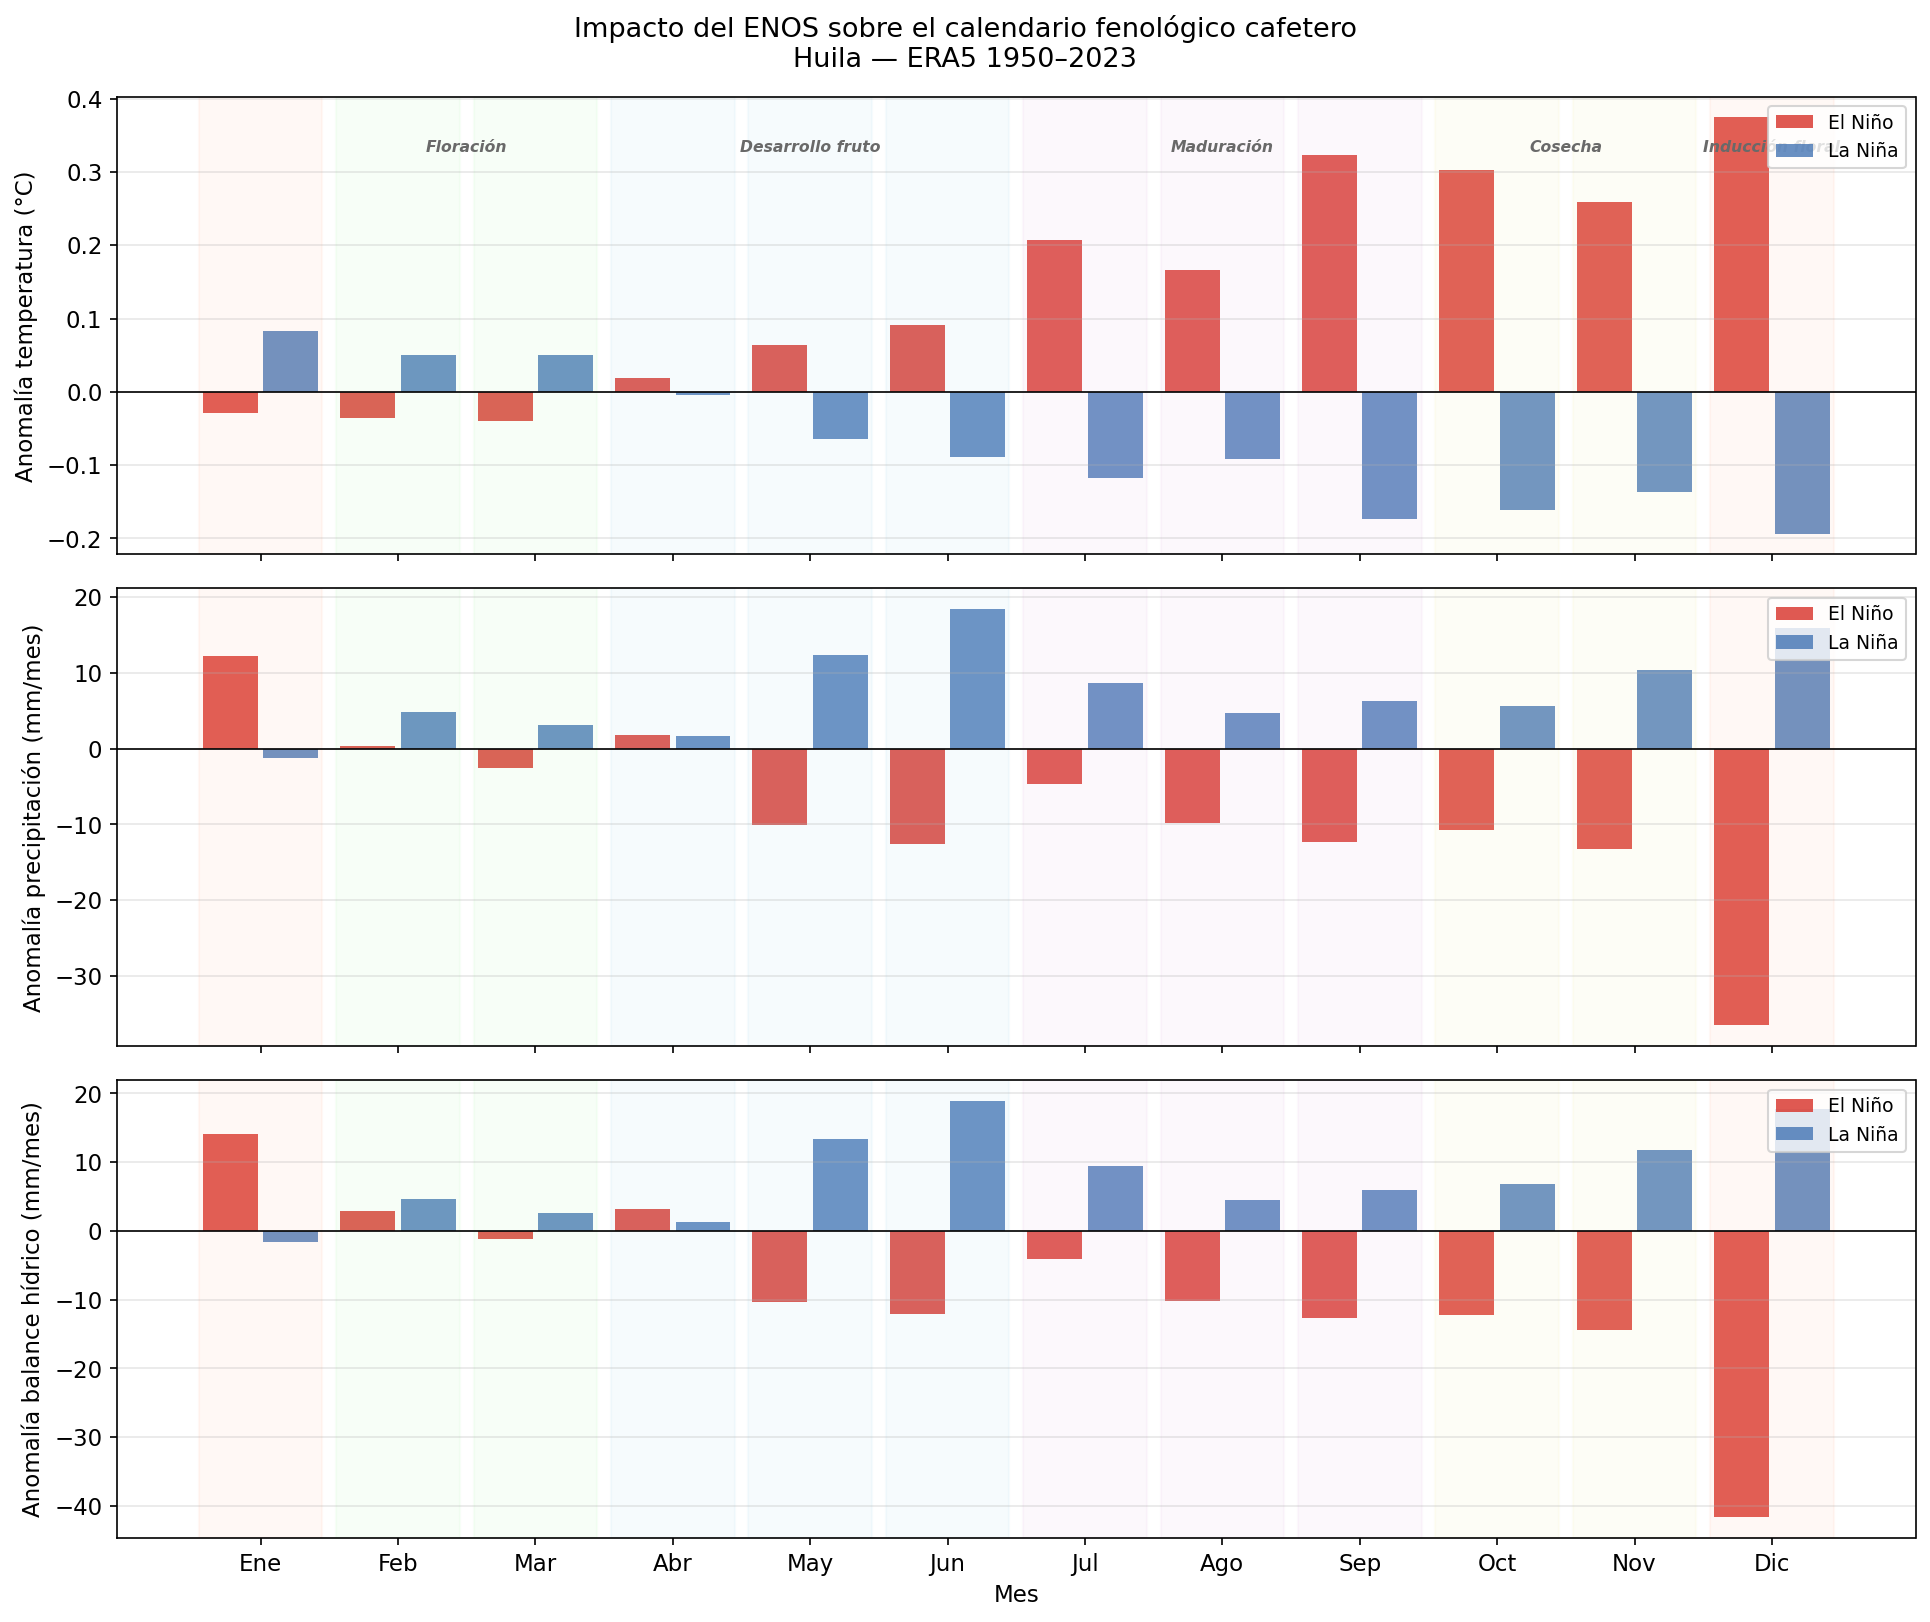


✓ Análisis completo.
Figuras generadas:
  fig01_nino34.png              → Serie temporal índice Niño 3.4
  fig02_ciclo_estacional.png    → Climatología mensual T, PP, BH
  fig03_espectral.png           → Espectro de potencia
  fig04_correlaciones_*.png     → Heatmap correlaciones mensuales
  fig05_composites_*.png        → Anomalías por fase ENOS
  fig06_umbrales_*.png          → Cumplimiento de umbrales fenológicos
  fig07_sintesis_*.png          → Síntesis integrada por departamento


In [20]:
for depto in DATOS:
    comp = COMP[depto]
    fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
    fig.suptitle(
        f'Impacto del ENOS sobre el calendario fenológico cafetero\n'
        f'{depto} — ERA5 1950–2023', fontsize=13, y=0.98
    )

    pares = [
        ('t2m_c', 'Anomalía temperatura (°C)'),
        ('tp_mm', 'Anomalía precipitación (mm/mes)'),
        ('bh_mm', 'Anomalía balance hídrico (mm/mes)'),
    ]
    for ax, (var, ylabel) in zip(axes, pares):
        n_vals = comp['El Niño'][var].values
        l_vals = comp['La Niña'][var].values
        mx = np.arange(1, 13)

        ax.bar(mx - 0.22, n_vals, 0.40,
               color='#d73027', alpha=0.80, label='El Niño')
        ax.bar(mx + 0.22, l_vals, 0.40,
               color='#4575b4', alpha=0.80, label='La Niña')
        ax.axhline(0, color='k', lw=0.8)
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, axis='y', alpha=0.3)

        for et in ETAPAS:
            for m in et['meses']:
                ax.axvspan(m - 0.45, m + 0.45, alpha=0.07, color=et['color'])

    # CORRECCIÓN: centros de etiquetas calculados correctamente.
    # 'Inducción floral' tiene meses=[12,1]: el promedio aritmético (6.5) es incorrecto
    # porque el ciclo es circular. Se usa el diccionario et_centros hardcodeado.
    et_centros = {
        'Inducción\nfloral':  12.0,   # se muestra sobre diciembre
        'Floración':           2.5,
        'Desarrollo\nfruto':  5.0,
        'Maduración':          8.0,
        'Cosecha':             10.5,
    }

    ylim = axes[0].get_ylim()
    y_txt = ylim[0] + (ylim[1] - ylim[0]) * 0.88
    for et in ETAPAS:
        nombre_limpio = et['nombre'].replace('\n', ' ')
        centro = et_centros.get(et['nombre'], np.mean(et['meses']))
        axes[0].text(centro, y_txt, nombre_limpio,
                     ha='center', fontsize=7.5, color='dimgray',
                     style='italic', fontweight='semibold')

    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(MESES)
    axes[-1].set_xlabel('Mes')
    plt.tight_layout()
    plt.savefig(f'fig07_sintesis_{depto}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\n✓ Análisis completo.')
print('Figuras generadas:')
figuras = [
    'fig01_nino34.png              → Serie temporal índice Niño 3.4',
    'fig02_ciclo_estacional.png    → Climatología mensual T, PP, BH',
    'fig03_espectral.png           → Espectro de potencia',
    'fig04_correlaciones_*.png     → Heatmap correlaciones mensuales',
    'fig05_composites_*.png        → Anomalías por fase ENOS',
    'fig06_umbrales_*.png          → Cumplimiento de umbrales fenológicos',
    'fig07_sintesis_*.png          → Síntesis integrada por departamento',
]
for f in figuras:
    print(f'  {f}')
